In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/cfb-datav2/cfb_drives.csv
/kaggle/input/cfb-datav2/cfb_lines.csv
/kaggle/input/cfb-datav2/cfb_games.csv


In [2]:
import requests
import time
import random
import ast

import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import math

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score, explained_variance_score, mean_absolute_error, mean_absolute_percentage_error, median_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, LeakyReLU, Input
from tensorflow.keras import regularizers
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

# Introduction

My project is focused on college football data. The source below was amazing and very detailed. I focused on three high level concepts of games, drives, and lines. One game will have multiple drives for each team in the match where each drive consists of one or more plays. Lines represents gambling data on game prior to kickoff. I felt lines would be interesting to bring into focus because it is essentially the expectations for the game. The features I chose in lines were the spread and over under. The spread is the expected win margin while the over under is total points scored. All the statistics I brought in from games and drives are specific to halftime. My motivation behind the project was to determine how close I could get to the final score difference with as much half time data as possible.

There are fetch functions for games, drives, and lines that utilize the api at the references listed below. The fetched api data was saved to CSVs and are in the dataset cfb-datav2. This iterates over 12 years of data where each year has 15 weeks. The data is specific to the regular season.

# References

https://collegefootballdata.com/

https://apinext.collegefootballdata.com/#/

In [3]:
def fetch_games():
    years = [2024, 2023, 2022, 2021, 2020, 2019, 2018, 2017, 2016, 2015, 2014, 2013]
    weeks = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]
    api_key = "pgBoDuAXuUfAWkS3ptiLU+NxBcIR0M2/D6aSnShVhnmxvU3+eVwwl9HDFI8lNXYs"
    headers = {
        "Authorization": f"Bearer {api_key}",
        "Accept": "application/json"
    }
    all_data = []
    for year in years:
        for week in weeks:
            url = f"https://apinext.collegefootballdata.com/games?year={year}&week={week}"
            response = requests.get(url, headers=headers)
            time.sleep(random.uniform(3, 7))
            if response.status_code == 200:
                data = response.json()
                all_data.extend(data)
                print(f"Week {week}, Year {year}: {len(data)} games found.")
            else:
                print(f"Error {response.status_code}: {response.text}")
                
    df = pd.DataFrame(all_data)
    df.to_csv("cfb_games.csv", index=False)
# fetch_games()

In [4]:
def fetch_lines():
    years = [2024, 2023, 2022, 2021, 2020, 2019, 2018, 2017, 2016, 2015, 2014, 2013]
    weeks = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]
    api_key = "pgBoDuAXuUfAWkS3ptiLU+NxBcIR0M2/D6aSnShVhnmxvU3+eVwwl9HDFI8lNXYs"
    headers = {
        "Authorization": f"Bearer {api_key}",
        "Accept": "application/json"
    }
    all_data = []
    for year in years:
        for week in weeks:
            url = f"https://apinext.collegefootballdata.com/lines?year={year}&week={week}"
            response = requests.get(url, headers=headers)
            time.sleep(random.uniform(1, 5))
            if response.status_code == 200:
                data = response.json()
                all_data.extend(data)
                print(f"Week {week}, Year {year}: {len(data)} games found.")
            else:
                print(f"Error {response.status_code}: {response.text}")
    df = pd.DataFrame(all_data)
    df.to_csv("cfb_lines.csv", index=False)
# fetch_lines()

In [5]:
def fetch_drives():
    years = [2024, 2023, 2022, 2021, 2020, 2019, 2018, 2017, 2016, 2015, 2014, 2013]
    weeks = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]
    api_key = "pgBoDuAXuUfAWkS3ptiLU+NxBcIR0M2/D6aSnShVhnmxvU3+eVwwl9HDFI8lNXYs"
    headers = {
        "Authorization": f"Bearer {api_key}",
        "Accept": "application/json"
    }
    all_data = []
    for year in years:
        for week in weeks:
            url = f"https://apinext.collegefootballdata.com/drives?year={year}&week={week}"
            response = requests.get(url, headers=headers)
            time.sleep(random.uniform(1, 5))
            if response.status_code == 200:
                data = response.json()
                all_data.extend(data)
                print(f"Week {week}, Year {year}: {len(data)} games found.")
            else:
                print(f"Error {response.status_code}: {response.text}")
    df = pd.DataFrame(all_data)
    df.to_csv("cfb_drives.csv", index=False)
# fetch_drives()

# Exploratory Data Analysis

In [6]:
pd.set_option('display.max_columns', None)

games = pd.read_csv("/kaggle/input/cfb-datav2/cfb_games.csv")
lines = pd.read_csv("/kaggle/input/cfb-datav2/cfb_lines.csv")
drives = pd.read_csv("/kaggle/input/cfb-datav2/cfb_drives.csv")


display(games.head(5))
display(lines.head(5))
display(drives.head(5))

print(games.shape)

/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,id,season,week,seasonType,startDate,startTimeTBD,completed,neutralSite,conferenceGame,attendance,venueId,venue,homeId,homeTeam,homeClassification,homeConference,homePoints,homeLineScores,homePostgameWinProbability,homePregameElo,homePostgameElo,awayId,awayTeam,awayClassification,awayConference,awayPoints,awayLineScores,awayPostgameWinProbability,awayPregameElo,awayPostgameElo,excitementIndex,highlights,notes
0,401693677,2024,1,regular,2024-08-24T04:00:00.000Z,True,True,True,False,NaN,NaN,NaN,124179,Lincoln (CA),ii,Independent DII,7.0,"[0, 0, 0, 7]",NaN,NaN,NaN,108382,College of Idaho,NaN,NaN,45.0,"[14, 7, 14, 10]",NaN,NaN,NaN,NaN,NaN,NaN
1,401635525,2024,1,regular,2024-08-24T16:00:00.000Z,False,True,True,True,NaN,3504.0,Aviva Stadium,59,Georgia Tech,fbs,ACC,24.0,"[7, 7, 0, 10]",0.991396,1497.0,1513.0,52,Florida State,fbs,ACC,21.0,"[8, 6, 0, 7]",0.008604,1692.0,1676.0,7.822224,NaN,Aer Lingus College Football Classic
2,401654665,2024,1,regular,2024-08-24T19:30:00.000Z,False,True,False,False,NaN,3827.0,"Memorial Stadium (Stephenville, TX)",2627,Tarleton State,fcs,UAC,26.0,"[16, 10, 0, 0]",0.054366,NaN,NaN,2377,McNeese,fcs,Southland,23.0,"[7, 0, 3, 13]",0.945634,NaN,NaN,5.564025,NaN,NaN
3,401643697,2024,1,regular,2024-08-24T20:00:00.000Z,False,True,False,False,NaN,3971.0,University Stadium (NM),167,New Mexico,fbs,Mountain West,31.0,"[10, 14, 7, 0]",0.301101,1234.0,1234.0,147,Montana State,fcs,Big Sky,35.0,"[0, 14, 0, 21]",0.698899,NaN,NaN,4.927318,NaN,NaN
4,401654662,2024,1,regular,2024-08-24T23:00:00.000Z,False,True,True,False,NaN,3689.0,Cramton Bowl,2546,Southeast Missouri State,fcs,Big South-OVC,37.0,"[7, 6, 8, 16]",0.994948,NaN,NaN,2453,North Alabama,fcs,UAC,15.0,"[8, 7, 0, 0]",0.005052,NaN,NaN,7.171901,NaN,FCS Kickoff


,id,season,seasonType,week,startDate,homeTeam,homeConference,homeClassification,homeScore,awayTeam,awayConference,awayClassification,awayScore,lines
0,401677192,2024,postseason,1,2025-01-21T00:30:00.000Z,Notre Dame,FBS Independents,fbs,23.0,Ohio State,Big Ten,fbs,34.0,"[{'provider': 'ESPN Bet', 'spread': 8.5, 'form..."
1,401677179,2024,postseason,1,2024-12-21T01:00:00.000Z,Notre Dame,FBS Independents,fbs,27.0,Indiana,Big Ten,fbs,17.0,"[{'provider': 'ESPN Bet', 'spread': -6.5, 'for..."
2,401634212,2024,regular,1,2024-08-31T18:00:00.000Z,Oklahoma State,Big 12,fbs,44.0,South Dakota State,MVFC,fcs,20.0,"[{'provider': 'ESPN Bet', 'spread': -12.5, 'fo..."
3,401677088,2024,postseason,1,2024-12-26T22:30:00.000Z,Kansas State,Big 12,fbs,44.0,Rutgers,Big Ten,fbs,41.0,"[{'provider': 'ESPN Bet', 'spread': -7.5, 'for..."
4,401636612,2024,regular,1,2024-08-31T23:00:00.000Z,Kansas State,Big 12,fbs,41.0,UT Martin,Big South-OVC,fcs,6.0,"[{'provider': 'ESPN Bet', 'spread': -36.5, 'fo..."


,id,gameId,offense,offenseConference,defense,defenseConference,driveNumber,scoring,startPeriod,startYardline,startYardsToGoal,startTime,endPeriod,endYardline,endYardsToGoal,endTime,plays,yards,driveResult,isHomeOffense,startOffenseScore,startDefenseScore,endOffenseScore,endDefenseScore
0,4016283191,401628319,Western Kentucky,Conference USA,Alabama,SEC,1,False,1,75,75,"{'minutes': 15, 'seconds': 0}",1,69,69,"{'minutes': 12, 'seconds': 50}",5,6,PUNT,False,0,0,0,0
1,4016283192,401628319,Alabama,SEC,Western Kentucky,Conference USA,2,False,1,31,69,"{'minutes': 12, 'seconds': 50}",1,28,72,"{'minutes': 11, 'seconds': 20}",3,-3,PUNT,True,0,0,0,0
2,4016283193,401628319,Western Kentucky,Conference USA,Alabama,SEC,3,False,1,80,80,"{'minutes': 11, 'seconds': 20}",1,78,78,"{'minutes': 10, 'seconds': 48}",2,2,INT,False,0,0,0,0
3,4016283194,401628319,Alabama,SEC,Western Kentucky,Conference USA,4,True,1,84,16,"{'minutes': 10, 'seconds': 48}",1,100,0,"{'minutes': 10, 'seconds': 7}",2,16,TD,True,0,0,7,0
4,4016283195,401628319,Western Kentucky,Conference USA,Alabama,SEC,5,False,1,75,75,"{'minutes': 10, 'seconds': 7}",1,22,22,"{'minutes': 6, 'seconds': 32}",8,53,INT,False,0,7,0,7


(25712, 33)


In [7]:
def clean_games(games):
    games = games.query("seasonType == 'regular' & (homeClassification == 'fbs' & awayClassification == 'fbs')")
    return games

games = clean_games(games)
print(games.shape)

(8524, 33)


In [8]:
def clean_lines(lines):
    def extract_first_valid(odds_list):
        """Finds the first provider with both spread and overUnder"""
        for odd in odds_list:
            if isinstance(odd, dict) and "spread" in odd and "overUnder" in odd:
                return odd.get("provider"), odd.get("spread"), odd.get("overUnder")
        return None, None, None
    
    lines["lines"] = lines["lines"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
    lines[["provider", "spread", "overUnder"]] = lines["lines"].apply(lambda x: pd.Series(extract_first_valid(x)))
    # lines.drop(columns=["lines"], inplace=True)
    return lines
    
lines = clean_lines(lines)
display(lines.head(5))

,id,season,seasonType,week,startDate,homeTeam,homeConference,homeClassification,homeScore,awayTeam,awayConference,awayClassification,awayScore,lines,provider,spread,overUnder
0,401677192,2024,postseason,1,2025-01-21T00:30:00.000Z,Notre Dame,FBS Independents,fbs,23.0,Ohio State,Big Ten,fbs,34.0,"[{'provider': 'ESPN Bet', 'spread': 8.5, 'form...",ESPN Bet,8.5,44.5
1,401677179,2024,postseason,1,2024-12-21T01:00:00.000Z,Notre Dame,FBS Independents,fbs,27.0,Indiana,Big Ten,fbs,17.0,"[{'provider': 'ESPN Bet', 'spread': -6.5, 'for...",ESPN Bet,-6.5,50.5
2,401634212,2024,regular,1,2024-08-31T18:00:00.000Z,Oklahoma State,Big 12,fbs,44.0,South Dakota State,MVFC,fcs,20.0,"[{'provider': 'ESPN Bet', 'spread': -12.5, 'fo...",ESPN Bet,-12.5,55.5
3,401677088,2024,postseason,1,2024-12-26T22:30:00.000Z,Kansas State,Big 12,fbs,44.0,Rutgers,Big Ten,fbs,41.0,"[{'provider': 'ESPN Bet', 'spread': -7.5, 'for...",ESPN Bet,-7.5,51.5
4,401636612,2024,regular,1,2024-08-31T23:00:00.000Z,Kansas State,Big 12,fbs,41.0,UT Martin,Big South-OVC,fcs,6.0,"[{'provider': 'ESPN Bet', 'spread': -36.5, 'fo...",ESPN Bet,-36.5,56.5


In [9]:
def clean_drives(drives):
    df = drives[drives['startPeriod'].isin([1, 2])].copy()

    def time_to_seconds(period, time_dict):
        """Converts start/end time to seconds, considering the game period."""
        total_minutes = (4 - period) * 15
        total_seconds = total_minutes * 60 + time_dict["minutes"] * 60 + time_dict["seconds"]
        return total_seconds

    df.loc[:, "startTime"] = df["startTime"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
    df.loc[:, "endTime"] = df["endTime"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

    print("Start Time Types:", df["startTime"].apply(type).unique())
    print("End Time Types:", df["endTime"].apply(type).unique())

    def calculate_possession_time(row):
        if isinstance(row["startTime"], dict) and isinstance(row["endTime"], dict):
            start_time_seconds = time_to_seconds(row["startPeriod"], row["startTime"])
            end_time_seconds = time_to_seconds(row["endPeriod"], row["endTime"])
            possession_time = start_time_seconds - end_time_seconds
        else:
            print(f"Invalid data for Drive {row['driveNumber']} in Game {row['gameId']}")
            possession_time = 0  # Handle the error gracefully
        return possession_time

    df.loc[:, "possession_time"] = df.apply(calculate_possession_time, axis=1)

    aggregated_df = df.groupby("gameId").agg({
        "isHomeOffense": [
            lambda x: x.sum(),
            lambda x: (~x).sum()
        ],
        "plays": [
            lambda x: x[df["isHomeOffense"]].sum(),
            lambda x: x[~df["isHomeOffense"]].sum()
        ],
        "possession_time": [
            lambda x: x[df["isHomeOffense"]].sum(),
            lambda x: x[~df["isHomeOffense"]].sum()
        ],
        "yards": [
            lambda x: x[df["isHomeOffense"]].sum(),
            lambda x: x[~df["isHomeOffense"]].sum()
        ]
    }).reset_index()

    aggregated_df.columns = [
        "gameId", 
        "home_drive_count", "away_drive_count", 
        "home_sum_plays", "away_sum_plays", 
        "home_time_of_possession", "away_time_of_possession", 
        "home_total_yards", "away_total_yards"
    ]
    
    return aggregated_df

drives = clean_drives(drives)
display(drives.head(10))
print(drives.shape)

Start Time Types: [<class 'dict'>]
End Time Types: [<class 'dict'>]


,gameId,home_drive_count,away_drive_count,home_sum_plays,away_sum_plays,home_time_of_possession,away_time_of_possession,home_total_yards,away_total_yards
0,332410006,6,5,35,30,846,954,155,161
1,332410023,7,7,38,33,802,998,220,97
2,332410041,7,6,32,29,885,915,181,171
3,332410062,10,8,42,37,937,863,70,177
4,332410084,10,11,40,47,739,1061,282,200
5,332410135,6,7,35,43,854,946,189,181
6,332410154,7,7,46,19,1331,469,258,98
7,332410189,7,8,45,36,1095,699,202,147
8,332410238,7,6,32,38,916,884,230,134
9,332410254,7,6,34,48,735,1065,232,300


(12050, 9)


In [10]:
print(games.columns)
print(lines.columns)
print(drives.columns)

def feature_reduction(lines, games, games_cols, lines_cols):
    lines = lines[lines_cols]
    games = games[games_cols]
    return lines, games

games_cols = ['id', 'season', 'week', 'startDate', 'homeId', 'homeTeam', 'homeClassification', 'homePoints', 'homeLineScores', 'awayId', 'awayTeam', 'awayClassification', 'awayPoints', 'awayLineScores']
lines_cols = ['id', 'spread', 'overUnder']
lines, games = feature_reduction(lines, games, games_cols, lines_cols)

print(games.shape)
print(lines.shape)
print(drives.shape)


Index(['id', 'season', 'week', 'seasonType', 'startDate', 'startTimeTBD',
       'completed', 'neutralSite', 'conferenceGame', 'attendance', 'venueId',
       'venue', 'homeId', 'homeTeam', 'homeClassification', 'homeConference',
       'homePoints', 'homeLineScores', 'homePostgameWinProbability',
       'homePregameElo', 'homePostgameElo', 'awayId', 'awayTeam',
       'awayClassification', 'awayConference', 'awayPoints', 'awayLineScores',
       'awayPostgameWinProbability', 'awayPregameElo', 'awayPostgameElo',
       'excitementIndex', 'highlights', 'notes'],
      dtype='object')
Index(['id', 'season', 'seasonType', 'week', 'startDate', 'homeTeam',
       'homeConference', 'homeClassification', 'homeScore', 'awayTeam',
       'awayConference', 'awayClassification', 'awayScore', 'lines',
       'provider', 'spread', 'overUnder'],
      dtype='object')
Index(['gameId', 'home_drive_count', 'away_drive_count', 'home_sum_plays',
       'away_sum_plays', 'home_time_of_possession', 'away_t

In [11]:
merged_games_lines = pd.merge(games, lines, left_on='id', right_on='id', how='inner')
games_lines_drives = pd.merge(merged_games_lines, drives, left_on='id', right_on='gameId', how='inner')
games_lines_drives = games_lines_drives.loc[:, ~games_lines_drives.columns.duplicated()]

display(games_lines_drives.head(10))
print(games_lines_drives.shape)

,id,season,week,startDate,homeId,homeTeam,homeClassification,homePoints,homeLineScores,awayId,awayTeam,awayClassification,awayPoints,awayLineScores,spread,overUnder,gameId,home_drive_count,away_drive_count,home_sum_plays,away_sum_plays,home_time_of_possession,away_time_of_possession,home_total_yards,away_total_yards
0,401635525,2024,1,2024-08-24T16:00:00.000Z,59,Georgia Tech,fbs,24.0,"[7, 7, 0, 10]",52,Florida State,fbs,21.0,"[8, 6, 0, 7]",10.5,54.5,401635525,3,4,23,33,803,997,154,194
1,401643696,2024,1,2024-08-25T00:00:00.000Z,2440,Nevada,fbs,24.0,"[7, 10, 7, 0]",2567,SMU,fbs,29.0,"[0, 10, 3, 16]",27.5,55.5,401643696,7,7,39,31,1170,603,196,101
2,401628448,2024,1,2024-08-30T00:00:00.000Z,135,Minnesota,fbs,17.0,"[0, 14, 0, 3]",153,North Carolina,fbs,19.0,"[0, 7, 6, 6]",1.5,52.5,401628448,6,6,33,26,1125,675,131,98
3,401640998,2024,1,2024-08-30T00:00:00.000Z,55,Jacksonville State,fbs,27.0,"[3, 7, 0, 17]",324,Coastal Carolina,fbs,55.0,"[17, 14, 10, 14]",-3.5,54.5,401640998,8,8,32,43,606,1171,131,317
4,401628453,2024,1,2024-08-30T23:00:00.000Z,127,Michigan State,fbs,16.0,"[2, 14, 0, 0]",2226,Florida Atlantic,fbs,10.0,"[0, 3, 7, 0]",-12.5,44.5,401628453,8,7,32,33,953,837,188,167
5,401628328,2024,1,2024-08-30T23:00:00.000Z,201,Oklahoma,fbs,51.0,"[17, 17, 3, 14]",218,Temple,fbs,3.0,"[0, 0, 3, 0]",-43.5,57.5,401628328,8,9,42,31,925,875,223,61
6,401628461,2024,1,2024-08-31T01:00:00.000Z,275,Wisconsin,fbs,28.0,"[0, 10, 3, 15]",2711,Western Michigan,fbs,14.0,"[0, 7, 0, 7]",-24.5,56.5,401628461,3,3,46,26,959,831,224,111
7,401634300,2024,1,2024-08-31T02:30:00.000Z,24,Stanford,fbs,27.0,"[7, 10, 0, 10]",2628,TCU,fbs,34.0,"[7, 3, 10, 14]",8.5,58.5,401634300,6,5,37,34,980,820,181,239
8,401628451,2024,1,2024-08-31T16:00:00.000Z,120,Maryland,fbs,50.0,"[14, 9, 13, 14]",41,UConn,fbs,7.0,"[0, 0, 7, 0]",-18.5,44.5,401628451,7,7,48,27,1086,704,330,93
9,401634305,2024,1,2024-08-31T16:00:00.000Z,221,Pittsburgh,fbs,55.0,"[14, 14, 14, 13]",2309,Kent State,fbs,24.0,"[7, 7, 10, 0]",-23.5,54.5,401634305,6,7,50,24,1067,708,320,63


(8480, 25)


In [12]:
print('NA Count per Feature')
print(games_lines_drives.isna().sum())
rows_with_missing = games_lines_drives[games_lines_drives.isna().any(axis=1)]
games_lines_drives = games_lines_drives.dropna()
print('Confirmation of NA values removed')
print(games_lines_drives.isna().sum())

NA Count per Feature
id                            0
season                        0
week                          0
startDate                     0
homeId                        0
homeTeam                      0
homeClassification            0
homePoints                    0
homeLineScores                0
awayId                        0
awayTeam                      0
awayClassification            0
awayPoints                    0
awayLineScores                0
spread                       21
overUnder                  1284
gameId                        0
home_drive_count              0
away_drive_count              0
home_sum_plays                0
away_sum_plays                0
home_time_of_possession       0
away_time_of_possession       0
home_total_yards              0
away_total_yards              0
dtype: int64
Confirmation of NA values removed
id                         0
season                     0
week                       0
startDate                  0
homeId          

Additional data cleaning below. Some data from api was invalid for total yards. We also see bad data for time of possession. Later in the project I found time of posession was not adding value to the models so elected to not use that feature and was able to bring in more rows because of that.

In [13]:
games_lines_drives = games_lines_drives.sort_values(by='home_total_yards', ascending=False)
display(games_lines_drives)

# BAD DATA TOTAL YARDS BY ID - 401012776, 401309858, 401301009
bad_total_yards = [401012776, 401309858, 401301009]
# Remove rows where the ID is in the list
games_lines_drives = games_lines_drives[~games_lines_drives['id'].isin(bad_total_yards)]

# REMOVE ROWS WHERE TIME OF POSSESION DATA IS BAD
time_sum = games_lines_drives['home_time_of_possession'] + games_lines_drives['away_time_of_possession']
count_equal_1800 = (time_sum == 1800).sum()
count_not_equal_1800 = (time_sum != 1800).sum()
print(f"Rows where sum == 1800: {count_equal_1800}")
print(f"Rows where sum != 1800: {count_not_equal_1800}")
df_not_equal_1800 = games_lines_drives[time_sum != 1800]
print("Rows where sum != 1800:")

# If we want to remove games where time of posession is incorrect run below. tradeoff between more data or this feature
# games_lines_drives = games_lines_drives[time_sum == 1800]
# # Remove rows where either column has a negative value
# games_lines_drives = games_lines_drives[
#     (games_lines_drives['home_time_of_possession'] >= 0) & 
#     (games_lines_drives['away_time_of_possession'] >= 0)
# ]

# ELECTING TO DROP COLUMNS AND KEEP MORE DATA BECAUSE OF THAT
games_lines_drives = games_lines_drives.drop(["home_time_of_possession", "away_time_of_possession"], axis=1)

,id,season,week,startDate,homeId,homeTeam,homeClassification,homePoints,homeLineScores,awayId,awayTeam,awayClassification,awayPoints,awayLineScores,spread,overUnder,gameId,home_drive_count,away_drive_count,home_sum_plays,away_sum_plays,home_time_of_possession,away_time_of_possession,home_total_yards,away_total_yards
2436,401301009,2021,4,2021-09-26T02:15:00.000Z,252,BYU,fbs,35.0,"[21, 7, 7, 0]",58,South Florida,fbs,27.0,"[0, 6, 14, 7]",-24.0,54.5,401301009,6,6,30,35,1720,980,1062,146
5048,400935356,2017,3,2017-09-16T23:30:00.000Z,213,Penn State,fbs,56.0,"[14, 21, 14, 7]",2247,Georgia State,fbs,0.0,"[0, 0, 0, 0]",-37.5,54.0,400935356,15,14,61,80,800,1948,654,304
8054,332780239,2013,6,2013-10-06T00:00:00.000Z,239,Baylor,fbs,73.0,"[28, 28, 10, 7]",277,West Virginia,fbs,42.0,"[7, 7, 7, 21]",-30.0,68.5,332780239,10,9,58,38,920,880,622,182
4477,401012303,2018,6,2018-10-06T20:00:00.000Z,145,Ole Miss,fbs,70.0,"[21, 28, 14, 7]",2433,UL Monroe,fbs,21.0,"[0, 7, 7, 7]",-23.0,76.0,401012303,7,8,43,46,782,964,546,275
81,401635532,2024,2,2024-09-08T00:00:00.000Z,228,Clemson,fbs,66.0,"[35, 21, 10, 0]",2026,App State,fbs,20.0,"[0, 13, 7, 0]",-13.5,53.5,401635532,8,9,41,45,906,864,540,180
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2343,401282791,2021,3,2021-09-18T17:00:00.000Z,38,Colorado,fbs,0.0,"[0, 0, 0, 0]",135,Minnesota,fbs,30.0,"[0, 13, 7, 10]",-2.5,49.0,401282791,6,6,25,35,716,1078,-3,220
5942,400869636,2016,6,2016-10-08T23:00:00.000Z,164,Rutgers,fbs,0.0,"[0, 0, 0, 0]",130,Michigan,fbs,78.0,"[14, 29, 14, 21]",30.0,52.5,400869636,10,11,30,39,850,950,-14,306
4190,401013437,2018,1,2018-08-26T02:00:00.000Z,166,New Mexico State,fbs,7.0,"[0, 0, 0, 7]",2751,Wyoming,fbs,29.0,"[9, 6, 7, 7]",5.0,47.0,401013437,7,7,21,42,527,1273,-18,188
2416,401309858,2021,4,2021-09-25T22:00:00.000Z,24,Stanford,fbs,24.0,"[0, 7, 7, 10]",26,UCLA,fbs,35.0,"[14, 7, 0, 14]",4.0,60.0,401309858,7,8,21,27,1392,1221,-91,173


Rows where sum == 1800: 4138
Rows where sum != 1800: 3034
Rows where sum != 1800:


Below is a conversion of scores from the original data set for homeLineScores and awayLineScores. This field was an array where each index represented the quarter and points scored. This was not great for modeling so broke each quarter and team out to its own column. I also added columns for total points and score differential. These values could be derived but felt this was easiest.

In [14]:
games_lines_drives["homeLineScores"] = games_lines_drives["homeLineScores"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
games_lines_drives["awayLineScores"] = games_lines_drives["awayLineScores"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

games_lines_drives["home_score_1q"] = games_lines_drives["homeLineScores"].apply(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else None)
games_lines_drives["away_score_1q"] = games_lines_drives["awayLineScores"].apply(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else None)
games_lines_drives["home_score_2q"] = games_lines_drives["homeLineScores"].apply(lambda x: x[1] if isinstance(x, list) and len(x) > 1 else None)
games_lines_drives["away_score_2q"] = games_lines_drives["awayLineScores"].apply(lambda x: x[1] if isinstance(x, list) and len(x) > 1 else None)

games_lines_drives["halftime_total_points"] = (
    games_lines_drives["home_score_1q"] + 
    games_lines_drives["away_score_1q"] + 
    games_lines_drives["home_score_2q"] + 
    games_lines_drives["away_score_2q"]
)

games_lines_drives["halftime_home_score_diff"] = (
    (games_lines_drives["home_score_1q"] + games_lines_drives["home_score_2q"]) - 
    (games_lines_drives["away_score_1q"] + games_lines_drives["away_score_2q"])
)

games_lines_drives["home_total_points"] = games_lines_drives["homeLineScores"].apply(lambda x: sum(x[:4]) if isinstance(x, list) and len(x) >= 4 else None)
games_lines_drives["away_total_points"] = games_lines_drives["awayLineScores"].apply(lambda x: sum(x[:4]) if isinstance(x, list) and len(x) >= 4 else None)

games_lines_drives["full_game_total_points"] = games_lines_drives["home_total_points"] + games_lines_drives["away_total_points"] 

games_lines_drives["full_game_home_score_diff"] = (
    games_lines_drives["home_total_points"]  - games_lines_drives["away_total_points"]
)

display(games_lines_drives.head(5))

,id,season,week,startDate,homeId,homeTeam,homeClassification,homePoints,homeLineScores,awayId,awayTeam,awayClassification,awayPoints,awayLineScores,spread,overUnder,gameId,home_drive_count,away_drive_count,home_sum_plays,away_sum_plays,home_total_yards,away_total_yards,home_score_1q,away_score_1q,home_score_2q,away_score_2q,halftime_total_points,halftime_home_score_diff,home_total_points,away_total_points,full_game_total_points,full_game_home_score_diff
5048,400935356,2017,3,2017-09-16T23:30:00.000Z,213,Penn State,fbs,56.0,"[14, 21, 14, 7]",2247,Georgia State,fbs,0.0,"[0, 0, 0, 0]",-37.5,54.0,400935356,15,14,61,80,654,304,14,0,21,0,35,35,56.0,0.0,56.0,56.0
8054,332780239,2013,6,2013-10-06T00:00:00.000Z,239,Baylor,fbs,73.0,"[28, 28, 10, 7]",277,West Virginia,fbs,42.0,"[7, 7, 7, 21]",-30.0,68.5,332780239,10,9,58,38,622,182,28,7,28,7,70,42,73.0,42.0,115.0,31.0
4477,401012303,2018,6,2018-10-06T20:00:00.000Z,145,Ole Miss,fbs,70.0,"[21, 28, 14, 7]",2433,UL Monroe,fbs,21.0,"[0, 7, 7, 7]",-23.0,76.0,401012303,7,8,43,46,546,275,21,0,28,7,56,42,70.0,21.0,91.0,49.0
81,401635532,2024,2,2024-09-08T00:00:00.000Z,228,Clemson,fbs,66.0,"[35, 21, 10, 0]",2026,App State,fbs,20.0,"[0, 13, 7, 0]",-13.5,53.5,401635532,8,9,41,45,540,180,35,0,21,13,69,43,66.0,20.0,86.0,46.0
1725,401404086,2022,5,2022-10-01T16:00:00.000Z,2628,TCU,fbs,55.0,"[27, 14, 14, 0]",201,Oklahoma,fbs,24.0,"[10, 7, 0, 7]",5.0,69.5,401404086,10,10,47,44,529,243,27,10,14,7,58,24,55.0,24.0,79.0,31.0


In [15]:
feature_cols = ['spread', 'overUnder', 'home_drive_count', 'away_drive_count',
       'home_sum_plays', 'away_sum_plays', 'home_total_yards', 'away_total_yards',
       'home_score_1q', 'away_score_1q', 'home_score_2q', 'away_score_2q',
       'halftime_total_points', 'halftime_home_score_diff',
       'home_total_points', 'away_total_points', 'full_game_total_points',
       'full_game_home_score_diff']

# Describe only the selected columns
games_lines_drives[feature_cols].describe()

,spread,overUnder,home_drive_count,away_drive_count,home_sum_plays,away_sum_plays,home_total_yards,away_total_yards,home_score_1q,away_score_1q,home_score_2q,away_score_2q,halftime_total_points,halftime_home_score_diff,home_total_points,away_total_points,full_game_total_points,full_game_home_score_diff
count,7172.000000,7172.000000,7172.000000,7172.000000,7172.000000,7172.000000,7172.000000,7172.000000,7172.000000,7172.000000,7172.000000,7172.000000,7172.000000,7172.000000,7170.000000,7170.000000,7170.000000,7170.000000
mean,-4.318670,55.178332,6.439626,6.481456,36.478109,35.732850,214.570134,193.959426,6.833659,5.455940,8.800613,7.540574,28.630786,2.637758,29.532636,25.458020,54.990656,4.074616
std,14.063202,8.216695,1.374857,1.372404,7.318668,7.365208,82.210852,79.228397,6.061422,5.425926,6.759581,6.286463,11.864305,14.577731,14.011049,13.498624,17.772427,21.004417
min,-55.000000,-1.000000,2.000000,2.000000,12.000000,11.000000,-18.000000,-19.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-49.000000,0.000000,0.000000,3.000000,-78.000000
25%,-13.500000,49.500000,6.000000,6.000000,32.000000,31.000000,157.750000,137.750000,0.000000,0.000000,3.000000,3.000000,20.000000,-7.000000,20.000000,16.000000,42.000000,-8.000000
50%,-3.500000,54.500000,6.000000,6.000000,36.000000,35.000000,209.000000,189.000000,7.000000,6.000000,7.000000,7.000000,28.000000,3.000000,28.000000,24.000000,54.000000,3.000000
75%,5.000000,60.500000,7.000000,7.000000,41.000000,40.000000,266.000000,242.250000,10.000000,7.000000,14.000000,12.000000,37.000000,11.000000,38.000000,34.000000,66.000000,18.000000
max,52.000000,90.000000,20.000000,17.000000,82.000000,82.000000,654.000000,618.000000,42.000000,35.000000,42.000000,42.000000,91.000000,65.000000,82.000000,78.000000,140.000000,74.000000


In [16]:
print('Checking NA value counts with new features')
print(games_lines_drives.isna().sum())
print('Confirming NA values removed')
games_lines_drives = games_lines_drives.dropna(axis=0, how='any')

Checking NA value counts with new features
id                           0
season                       0
week                         0
startDate                    0
homeId                       0
homeTeam                     0
homeClassification           0
homePoints                   0
homeLineScores               0
awayId                       0
awayTeam                     0
awayClassification           0
awayPoints                   0
awayLineScores               0
spread                       0
overUnder                    0
gameId                       0
home_drive_count             0
away_drive_count             0
home_sum_plays               0
away_sum_plays               0
home_total_yards             0
away_total_yards             0
home_score_1q                0
away_score_1q                0
home_score_2q                0
away_score_2q                0
halftime_total_points        0
halftime_home_score_diff     0
home_total_points            2
away_total_points          

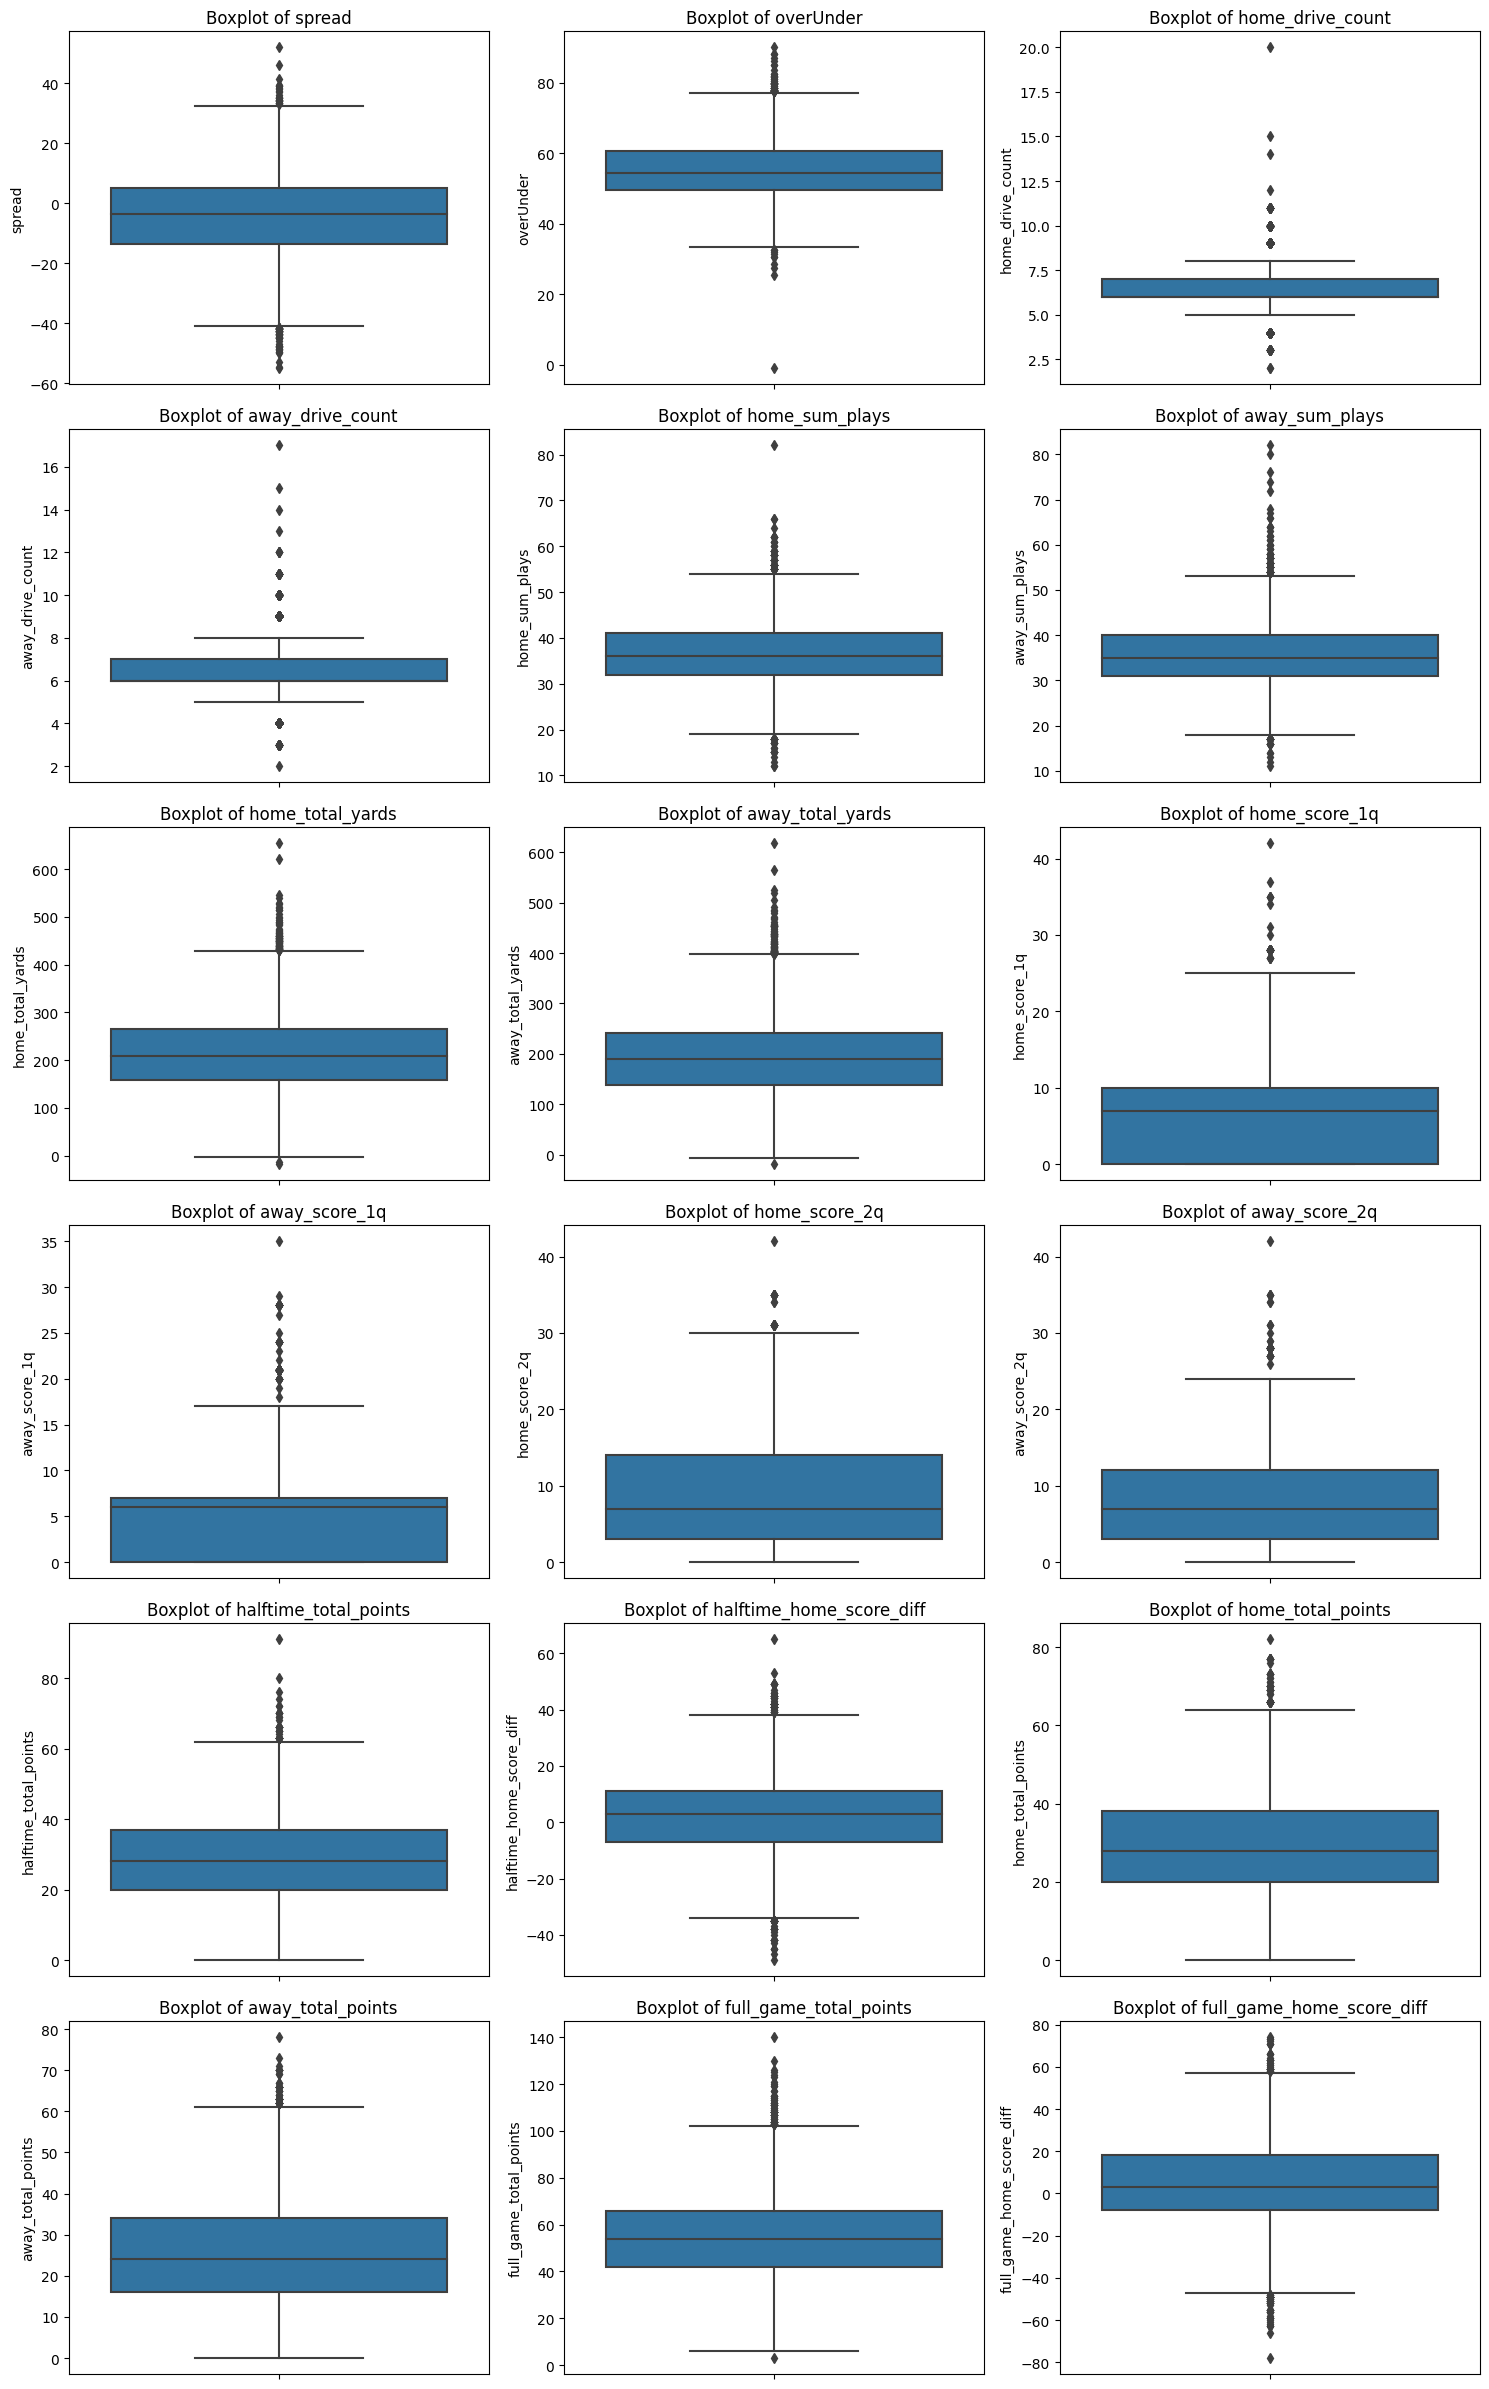

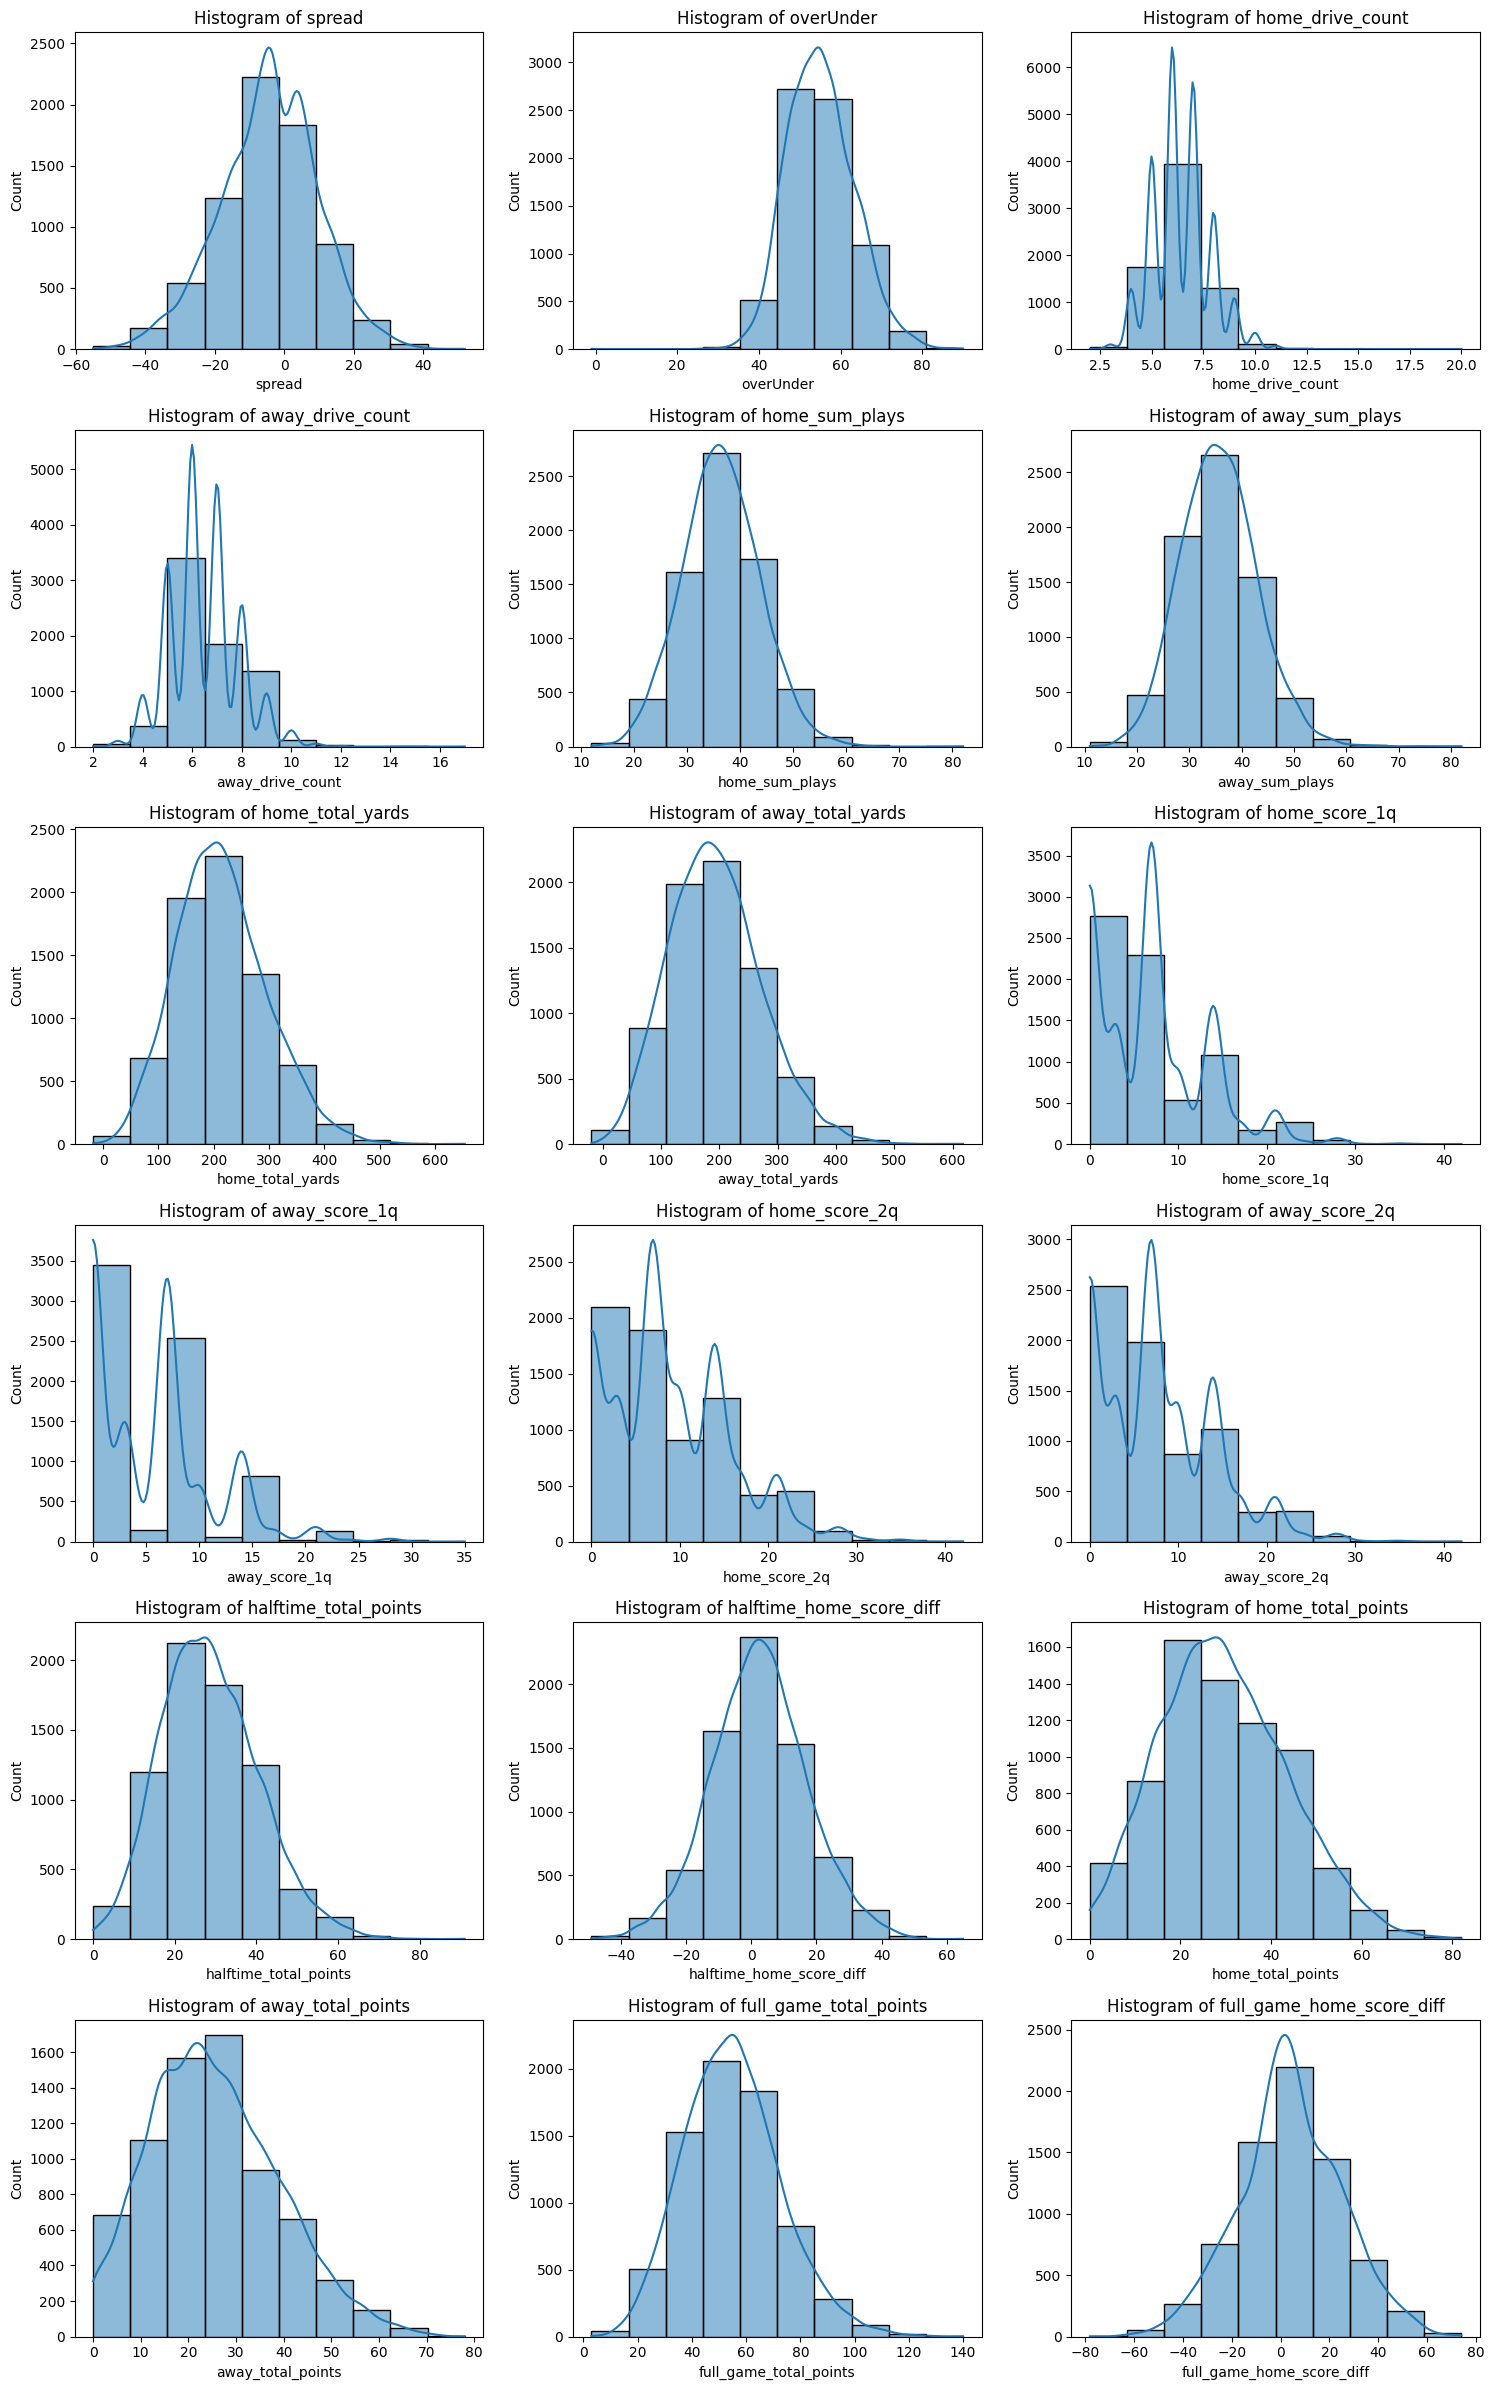

In [17]:
warnings.simplefilter(action='ignore', category=FutureWarning)

num_features = len(feature_cols)
num_cols = 3
num_rows = math.ceil(num_features / num_cols)

fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(15, 4 * num_rows))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    sns.boxplot(y=games_lines_drives[col], ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}')

for i in range(num_features, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(15, 4 * num_rows))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    sns.histplot(games_lines_drives[col], kde=True, bins=10, ax=axes[i])
    axes[i].set_title(f'Histogram of {col}')

for i in range(num_features, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

Scaling was applied due to the magnitude differences in the features, as "yards" will be much higher than the others. A log transformation isn't necessary unless dealing with points by quarter. Missing data was handled earlier, and while there were minor outliers, I didn't remove them given the large volume of data.

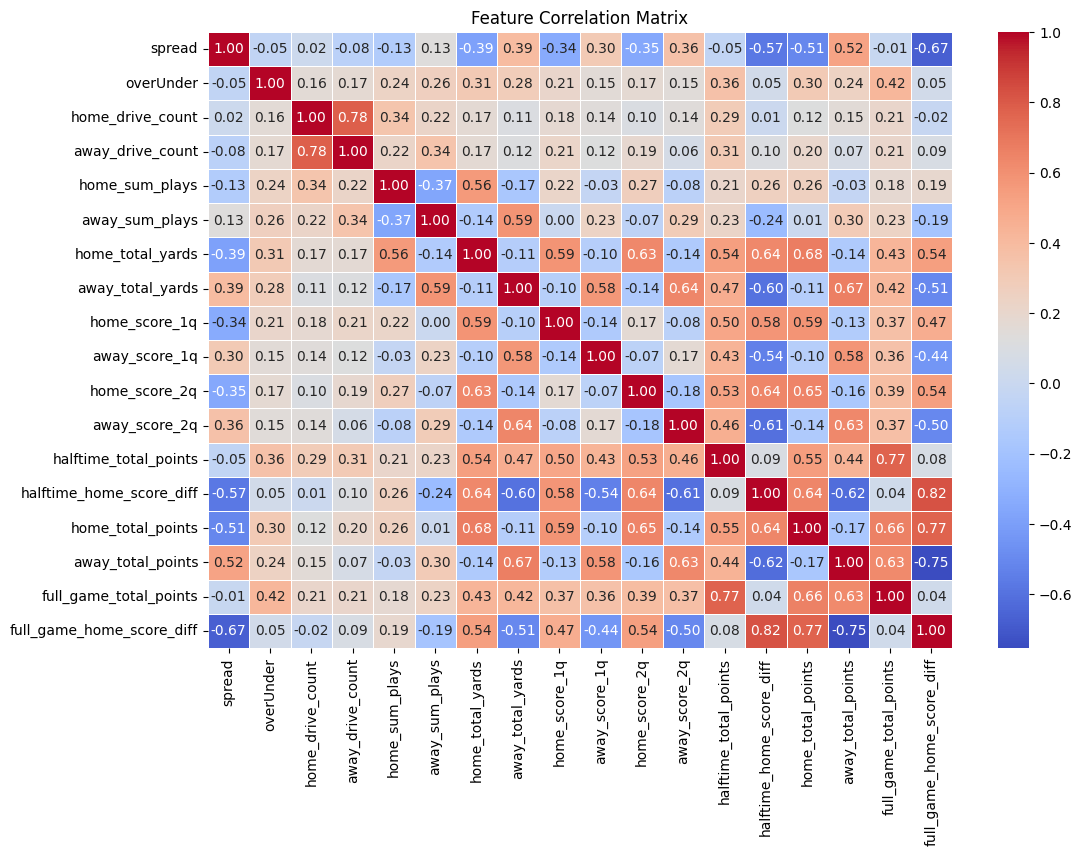

spread                      -0.673255
overUnder                    0.045752
home_drive_count            -0.017847
away_drive_count             0.085708
home_sum_plays               0.193237
away_sum_plays              -0.187244
home_total_yards             0.538848
away_total_yards            -0.505834
home_score_1q                0.470942
away_score_1q               -0.441143
home_score_2q                0.536371
away_score_2q               -0.499878
halftime_total_points        0.079756
halftime_home_score_diff     0.824391
home_total_points            0.773516
away_total_points           -0.753162
full_game_total_points       0.037762
full_game_home_score_diff    1.000000
Name: full_game_home_score_diff, dtype: float64

,Feature,VIF
0,spread,1.542620
1,overUnder,1.354107
2,home_drive_count,2.990270
3,away_drive_count,3.048517
4,home_sum_plays,2.370744
5,away_sum_plays,2.518162
6,home_total_yards,4.193329
7,away_total_yards,4.385628
8,halftime_total_points,2.638940
9,halftime_home_score_diff,4.142407


In [18]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

corr_matrix = games_lines_drives[feature_cols].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Matrix")
plt.show()

target = "full_game_home_score_diff"
corr_values = corr_matrix.loc[target]
display(corr_values)


feats_to_use = ['spread', 'overUnder', 'home_drive_count', 'away_drive_count',
       'home_sum_plays', 'away_sum_plays', 'home_total_yards', 'away_total_yards',
       'halftime_total_points', 'halftime_home_score_diff']


df_selected = games_lines_drives[feats_to_use].copy()
df_selected = df_selected.assign(const=1)
vif_data = pd.DataFrame()
vif_data["Feature"] = df_selected.columns
vif_data["VIF"] = [variance_inflation_factor(df_selected.values, i) for i in range(df_selected.shape[1])]
display(vif_data[vif_data["Feature"] != "const"].reset_index(drop=True))

The goal above was to start broad and filter down to the appropriate features to use in the models. Many columns at first were redundant especially with scoring by quarter then halftime.

The correlation values against the full_game_home_score_diff logically make sense. halftime_home_score_diff is the strong indicator of what the full_game_home_score_diff will be. The spread has a correlation of -0.673 which also makes sense. A negative spread indicates the home team is favorite so should work inversely against the full_game_home_score_diff. At -.673 it also makes sense in terms of value being that its half the game. 

I was happy with the VIF scores and expected moderate collinearity between the drives, plays, and yards as they are tied together.

In [19]:
games_lines_drives.shape
display(games_lines_drives[feats_to_use])

,spread,overUnder,home_drive_count,away_drive_count,home_sum_plays,away_sum_plays,home_total_yards,away_total_yards,halftime_total_points,halftime_home_score_diff
5048,-37.5,54.0,15,14,61,80,654,304,35,35
8054,-30.0,68.5,10,9,58,38,622,182,70,42
4477,-23.0,76.0,7,8,43,46,546,275,56,42
81,-13.5,53.5,8,9,41,45,540,180,69,43
1725,5.0,69.5,10,10,47,44,529,243,58,24
...,...,...,...,...,...,...,...,...,...,...
4416,-3.5,63.0,7,8,26,38,14,214,28,-14
4620,1.5,48.0,5,4,13,44,-1,248,16,-16
2343,-2.5,49.0,6,6,25,35,-3,220,13,-13
5942,30.0,52.5,10,11,30,39,-14,306,43,-43


# Neural Net Models

1. Base Model:
- A simple feed-forward neural network with three layers.
- Two hidden layers with 64 and 32 neurons, using ReLU activation.
- Output layer with 1 neuron (for regression).
- No batch normalization or dropout applied.

2. Batch Normalization Model:
- Similar to the base model, but includes batch normalization layers.
- Batch normalization is applied after each dense layer to stabilize training.
- Helps the model train faster and with higher stability.

3. Dropout Model:
- Uses dropout for regularization.
- A 0.3 dropout rate is applied after the first hidden layer to prevent overfitting.
- The model has two hidden layers with 128 and 64 neurons, using ReLU activation.

4. Wider Dropout Model:
- A variant of the dropout model with more hidden units.
- The first hidden layer has 256 neurons, and the second has 128 neurons.
- Dropout is applied after the first layer (0.3 rate).

5. Deeper Dropout Model:
- A deeper variant of the dropout model.
- Contains four hidden layers with dropout applied after each one (0.3 rate).
- Hidden layers have sizes: 128, 128, 128, and 64 neurons, using ReLU activation.

6. L1/L2 Regularized Model:
- This model uses L1 and L2 regularization to prevent overfitting.
- Each dense layer has both L1 and L2 regularizers (with a value of 0.01).
- The model has three hidden layers with 128, 64, and 32 neurons, using ReLU activation.

7. Increasing Layers Model:
- A more complex model with increasing and then decreasing layer sizes.
- The hidden layers progressively increase in size from 64 to 512 neurons, then decrease back to 64.
- The model aims to capture more complex patterns with larger layers initially.

8. Leaky ReLU Model:
- A model that uses Leaky ReLU activation functions instead of standard ReLU.
- Leaky ReLU allows for a small, non-zero gradient when the input is negative.
- The model has three hidden layers with 128, 64, and 32 neurons.

9. SGD Model:
- A model that uses the SGD (Stochastic Gradient Descent) optimizer instead of Adam.
- It has three hidden layers with 128, 64, and 32 neurons.
- The learning rate is set to 0.01 with momentum of 0.9 for the optimizer.



In [20]:
def train_and_evaluate_models_with_features(games_lines_drives, feats_to_use, target="full_game_total_points", test_size=0.2, random_state=42, epochs=50, batch_size=32, learning_rate=0.001):
    X = games_lines_drives[feats_to_use].values
    y = games_lines_drives[target].values
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    histories = {}
    metrics_dict = {}
    feature_importances = {}
    results_df = pd.DataFrame(columns=["Model Name", "Params", "R² Score", "Explained Variance Score", "MeanAE", "MedianAE"])

    def train_and_evaluate_model(model, name, params, early_stopping=None):
        optimizer = Adam(learning_rate=learning_rate)
        model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

        callbacks = [early_stopping] if early_stopping else []

        history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_data=(X_test, y_test), verbose=0, callbacks=callbacks)
        histories[name] = history.history

        loss, mae = model.evaluate(X_test, y_test)
        y_pred = model.predict(X_test)

        metrics_dict[name] = {
            "R² Score": r2_score(y_test, y_pred),
            "Explained Variance Score": explained_variance_score(y_test, y_pred),
            "MeanAE": mean_absolute_error(y_test, y_pred),
            "MedianAE": median_absolute_error(y_test, y_pred)
        }

        results_df.loc[len(results_df)] = [
            name,
            params,
            metrics_dict[name]["R² Score"],
            metrics_dict[name]["Explained Variance Score"],
            metrics_dict[name]["MeanAE"],
            metrics_dict[name]["MedianAE"]
        ]

    def create_base_model():
        model = Sequential([
            Input(shape=(X_train.shape[1],)),
            Dense(64, activation='relu'),
            Dense(32, activation='relu'),
            Dense(1)
        ])
        return model

    def create_batch_norm_model():
        model = Sequential([
            Input(shape=(X_train.shape[1],)),
            Dense(128, activation='relu'),
            BatchNormalization(),
            Dense(64, activation='relu'),
            BatchNormalization(),
            Dense(32, activation='relu'),
            Dense(1)
        ])
        return model

    def create_dropout_model():
        model = Sequential([
            Input(shape=(X_train.shape[1],)),
            Dense(128, activation='relu'),
            Dropout(0.3),
            Dense(64, activation='relu'),
            Dense(1)
        ])
        return model

    def create_wider_dropout_model():
        model = Sequential([
            Input(shape=(X_train.shape[1],)),
            Dense(256, activation='relu'),
            Dropout(0.3),
            Dense(128, activation='relu'),
            Dense(64, activation='relu'),
            Dense(1)
        ])
        return model

    def create_deeper_dropout_model():
        model = Sequential([
            Input(shape=(X_train.shape[1],)),
            Dense(128, activation='relu'),
            Dropout(0.3),
            Dense(128, activation='relu'),
            Dropout(0.3),
            Dense(128, activation='relu'),
            Dropout(0.3),
            Dense(64, activation='relu'),
            Dense(1)
        ])
        return model

    def create_l1_l2_regularized_model():
        model = Sequential([
            Input(shape=(X_train.shape[1],)),
            Dense(128, activation='relu', kernel_regularizer=regularizers.l1_l2(l1=0.01, l2=0.01)),
            Dense(64, activation='relu', kernel_regularizer=regularizers.l1_l2(l1=0.01, l2=0.01)),
            Dense(32, activation='relu', kernel_regularizer=regularizers.l1_l2(l1=0.01, l2=0.01)),
            Dense(1)
        ])
        return model

    def create_increasing_layers_model():
        model = Sequential([
            Input(shape=(X_train.shape[1],)),
            Dense(64, activation='relu'),
            Dense(128, activation='relu'),
            Dense(256, activation='relu'),
            Dense(512, activation='relu'),
            Dense(256, activation='relu'),
            Dense(128, activation='relu'),
            Dense(64, activation='relu'),
            Dense(1)
        ])
        return model

    def create_leaky_relu_model():
        model = Sequential([
            Input(shape=(X_train.shape[1],)),
            Dense(128),
            LeakyReLU(negative_slope=0.1),
            Dense(64),
            LeakyReLU(negative_slope=0.1),
            Dense(32),
            LeakyReLU(negative_slope=0.1),
            Dense(1)
        ])
        return model

    def create_sgd_model():
        model = Sequential([
            Input(shape=(X_train.shape[1],)),
            Dense(128, activation='relu'),
            Dense(64, activation='relu'),
            Dense(32, activation='relu'),
            Dense(1)
        ])
        optimizer = SGD(learning_rate=0.01, momentum=0.9)
        model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
        return model
        
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        min_delta=0.0001
    )

    models = {
        "base_model": create_base_model(),
        "batch_norm_model": create_batch_norm_model(),
        "dropout_model": create_dropout_model(),
        "wider_dropout_model": create_wider_dropout_model(),
        "deeper_dropout_model": create_deeper_dropout_model(),
        "l1_l2_regularized_model": create_l1_l2_regularized_model(),
        "increasing_layers_model": create_increasing_layers_model(),
        "leaky_relu_model": create_leaky_relu_model(),
        "sgd_model": create_sgd_model()
    }

    for name, model in models.items():
        params = {
            'learning_rate': learning_rate,
            'batch_size': batch_size,
            'epochs': epochs
        }
        train_and_evaluate_model(model, name, params, early_stopping)
    return histories, metrics_dict, results_df

In [21]:
def plot_model_performance(histories, exclude_names=None):
    if exclude_names is None:
        exclude_names = []

    colors = sns.color_palette("Set2", len(histories))

    plt.figure(figsize=(14, 8))
    for i, (name, history) in enumerate(histories.items()):
        if name in exclude_names:
            continue

        color = colors[i]
        plt.subplot(1, 2, 1)
        plt.plot(history['mae'], label=f'{name} Train MedianAE', color=color)
        plt.plot(history['val_mae'], label=f'{name} Val MedianAE', color=color, linestyle='--')
        plt.xlabel('Epochs')
        plt.ylabel('Median Absolute Error (MedianAE)')
        plt.legend()
        plt.title('Train MedianAE vs. Validation MedianAE')

        plt.subplot(1, 2, 2)
        plt.plot(history['loss'], label=f'{name} Train Loss', color=color)
        plt.plot(history['val_loss'], label=f'{name} Val Loss', color=color, linestyle='--')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.title('Train Loss vs. Validation Loss')

    plt.tight_layout()
    plt.show()

LEARNING RATE=0.1, BATCH_SIZE=8, EPOCHS=50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 113.0554 - mae: 8.4610 
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 157.9653 - mae: 9.8813
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 142.4457 - mae: 9.4842
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 384.5974 - mae: 15.4246
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 457.4729 - mae: 16.6092
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 191.9048 - mae: 10.3232
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 470.0366 - mae: 16.7905
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 144.9662 - mae: 9.5168 
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 118.5685 - mae: 8.7385 
45/45 ━━

None

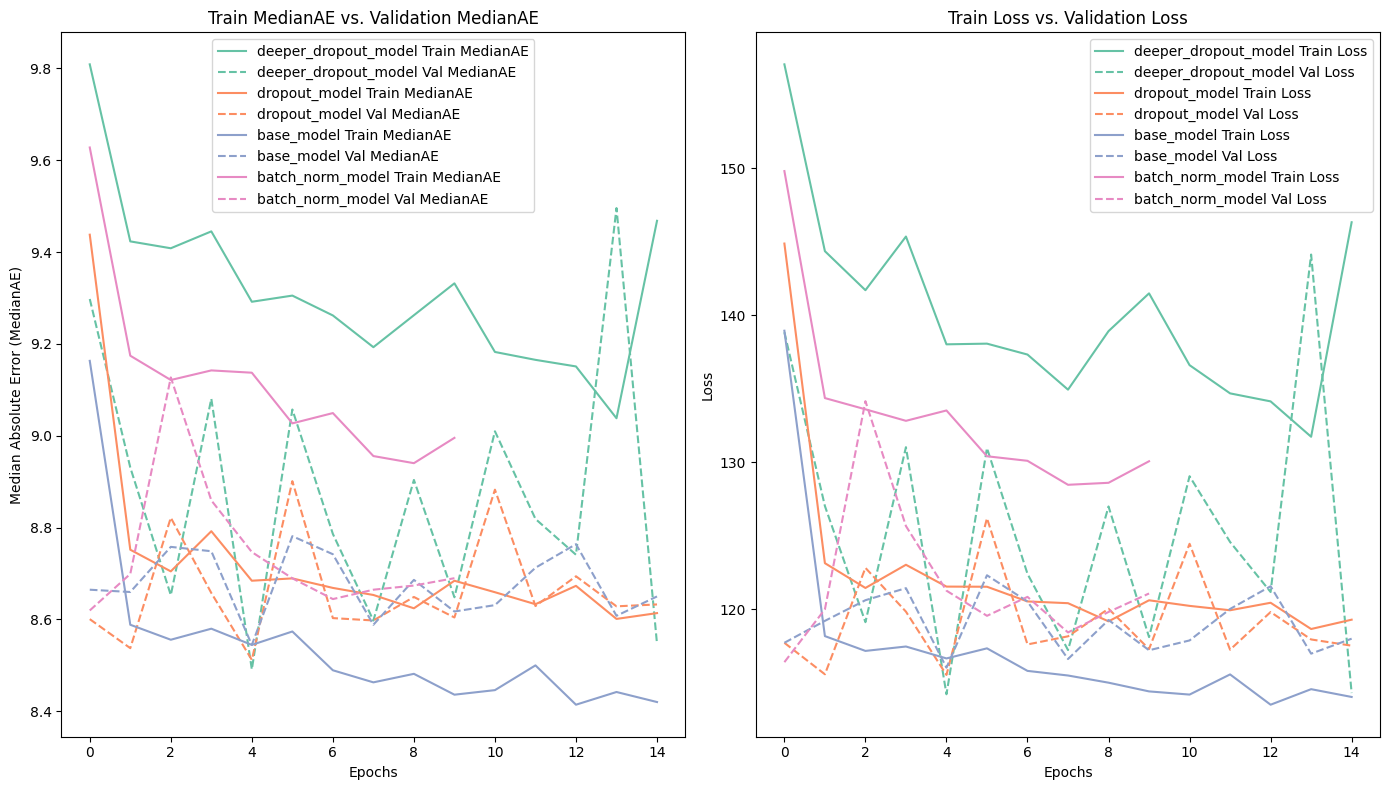

LEARNING RATE=0.01, BATCH_SIZE=64, EPOCHS=50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 110.9908 - mae: 8.4867 
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 133.6026 - mae: 9.2693  
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 108.9684 - mae: 8.3667
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 125.6238 - mae: 9.0026 
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 116.1689 - mae: 8.6058 
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 126.3222 - mae: 8.7107  
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 116.5376 - mae: 8.6237
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 113.0757 - mae: 8.5455 
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 109.0787 - mae: 8.4204
45/45

None

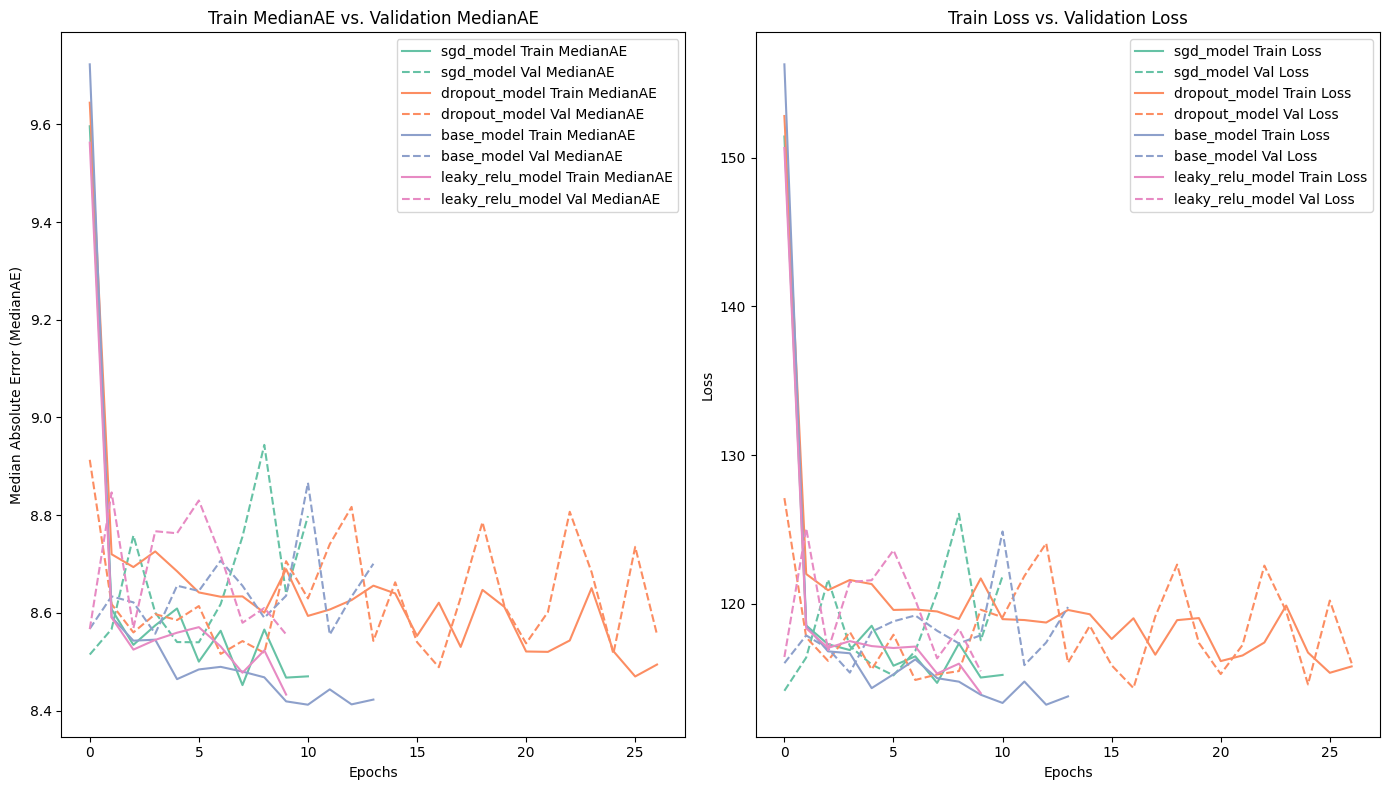

LEARNING RATE=0.01, BATCH_SIZE=128, EPOCHS=50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 111.2534 - mae: 8.4499
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 154.1380 - mae: 9.8529  
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 118.7598 - mae: 8.7513 
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 115.4015 - mae: 8.5968 
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 124.2245 - mae: 8.8960 
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 126.6258 - mae: 8.6487  
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 158.7974 - mae: 10.0795
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 111.2207 - mae: 8.4500 
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 115.0565 - mae: 8.6417 
45

None

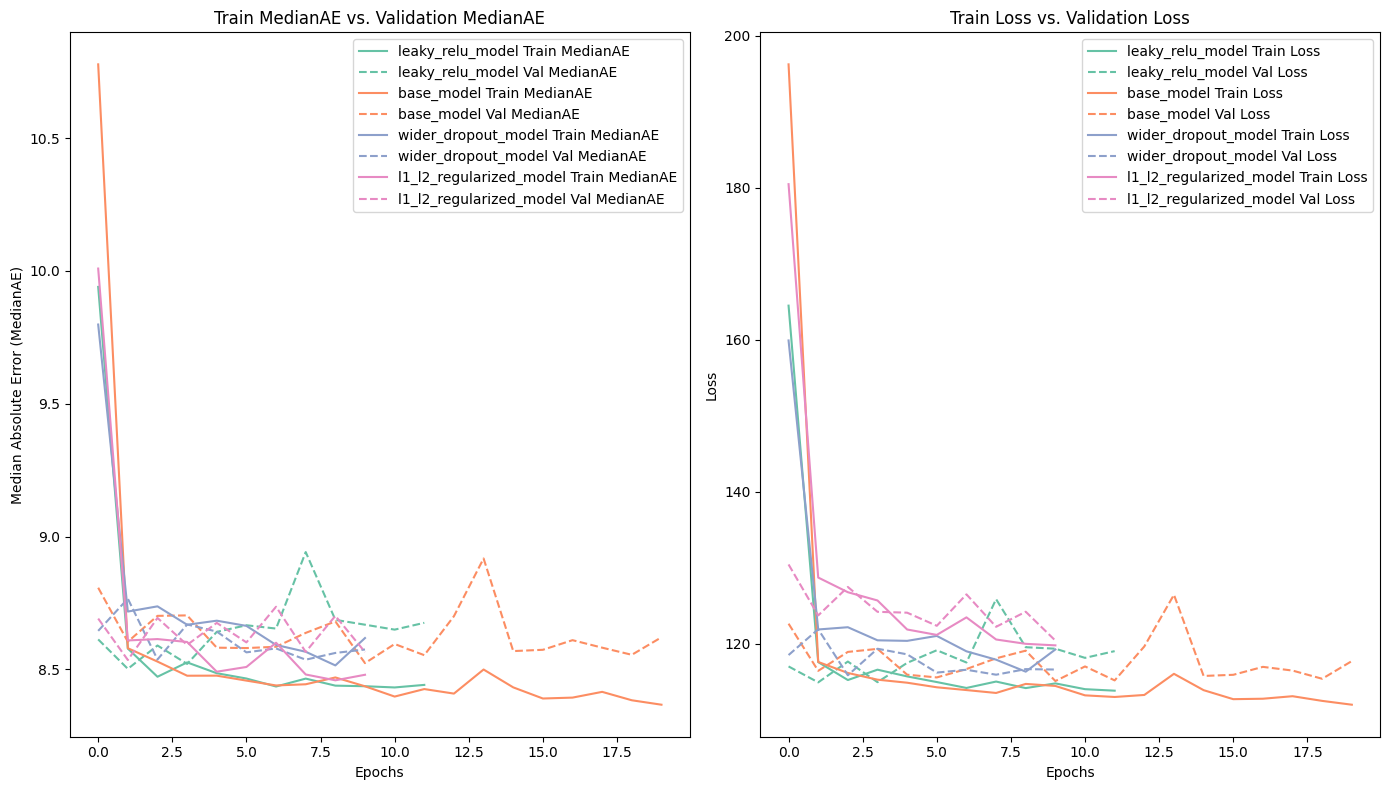

LEARNING RATE=0.001, BATCH_SIZE=16, EPOCHS=50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 109.5609 - mae: 8.4121
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 123.9547 - mae: 8.8847
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 115.2653 - mae: 8.6672 
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 108.8757 - mae: 8.3779
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 109.6435 - mae: 8.4301 
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 126.9726 - mae: 8.6439  
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 117.8337 - mae: 8.7491
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 112.2417 - mae: 8.5323
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 109.6005 - mae: 8.4290
45/45 ━━

None

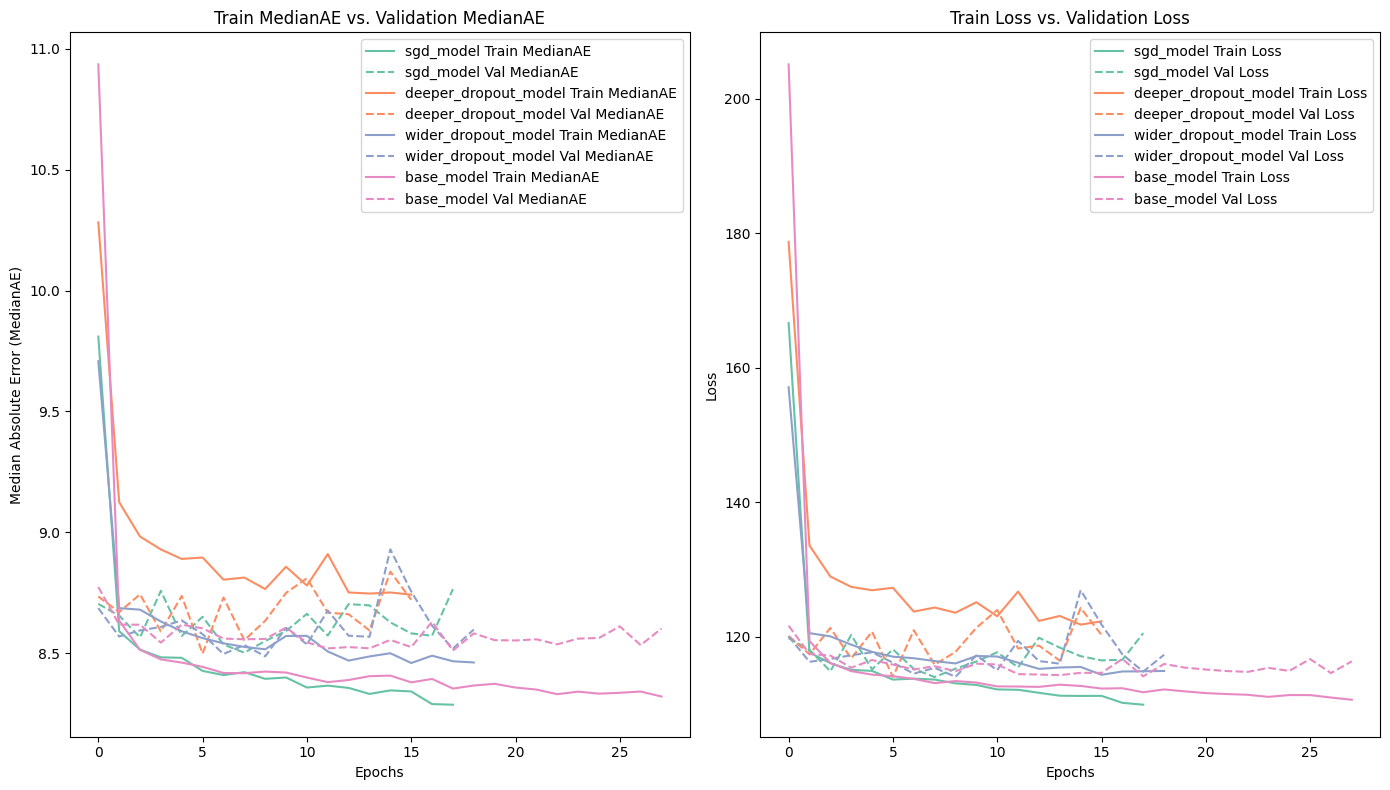

LEARNING RATE=0.001, BATCH_SIZE=32, EPOCHS=50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 108.8667 - mae: 8.4224
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 201.2341 - mae: 11.1049
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 118.1700 - mae: 8.7984 
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 115.0827 - mae: 8.5968 
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 108.2109 - mae: 8.3664
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 126.8502 - mae: 8.6090
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 112.9103 - mae: 8.5760
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 116.5825 - mae: 8.7611 
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 113.9070 - mae: 8.5514
45/45 ━━

None

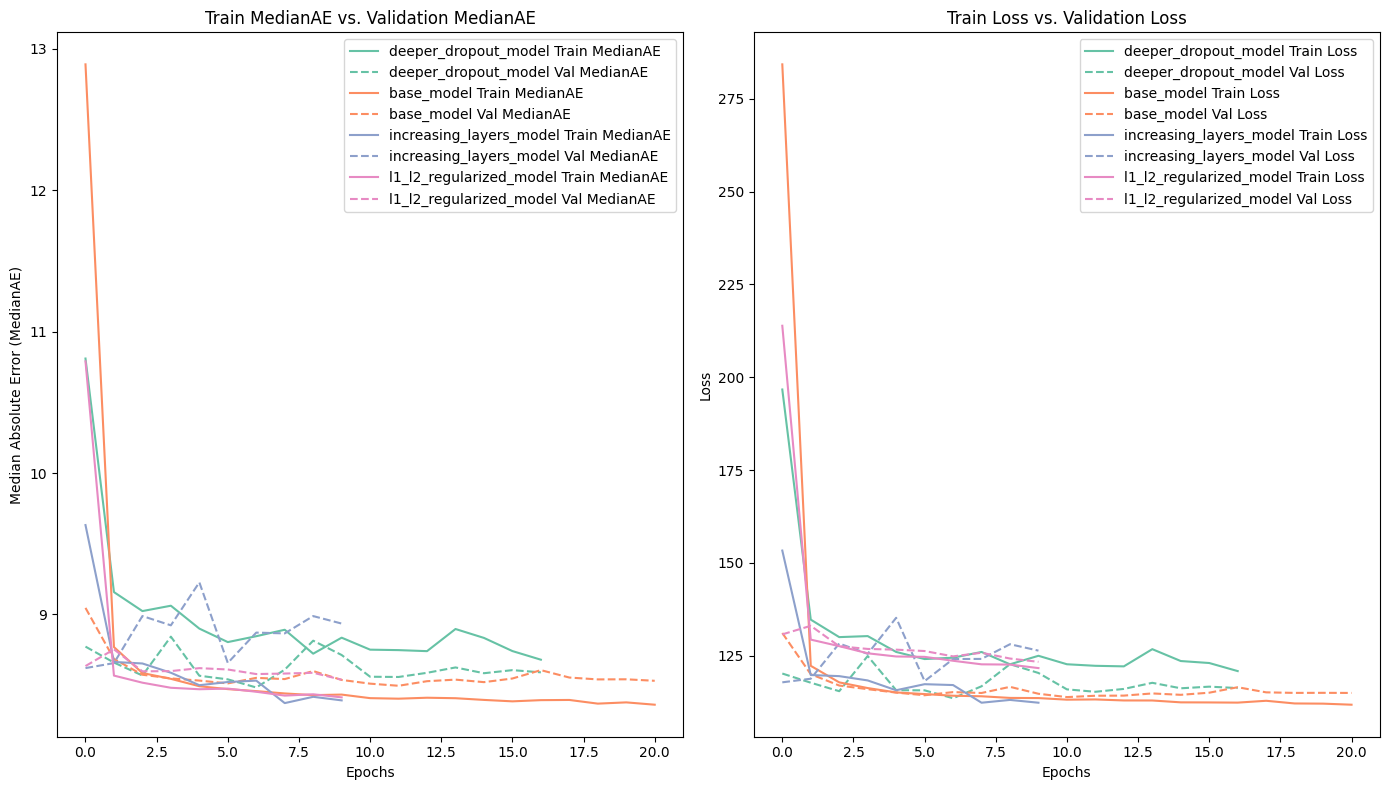

LEARNING RATE=0.001, BATCH_SIZE=64, EPOCHS=50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 110.0670 - mae: 8.4666
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 244.5675 - mae: 12.1242
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 110.3287 - mae: 8.4448 
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 114.8927 - mae: 8.6342 
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 123.5331 - mae: 8.9813 
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 138.9677 - mae: 9.0245  
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 116.7671 - mae: 8.6640
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 127.2291 - mae: 9.1645  
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 109.6254 - mae: 8.4381
45/4

None

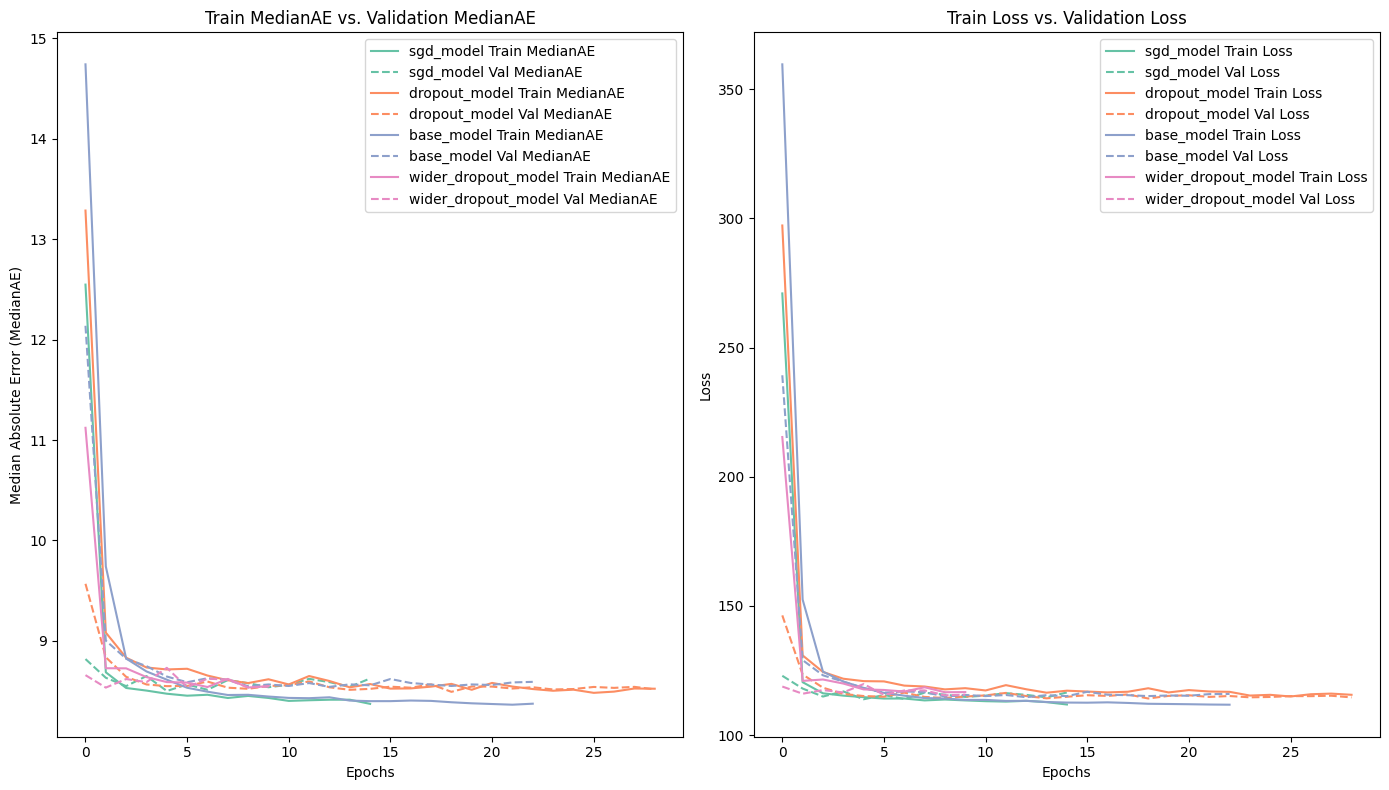

LEARNING RATE=0.0001, BATCH_SIZE=4, EPOCHS=50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 109.8496 - mae: 8.4353
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 138.7014 - mae: 9.3812
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 188.0871 - mae: 10.7334
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 114.8652 - mae: 8.6280
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 133.2124 - mae: 9.2581 
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 141.5275 - mae: 9.0906 
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 122.8252 - mae: 8.9603
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 124.8705 - mae: 8.9304 
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 129.3770 - mae: 9.0998  
45/45 

None

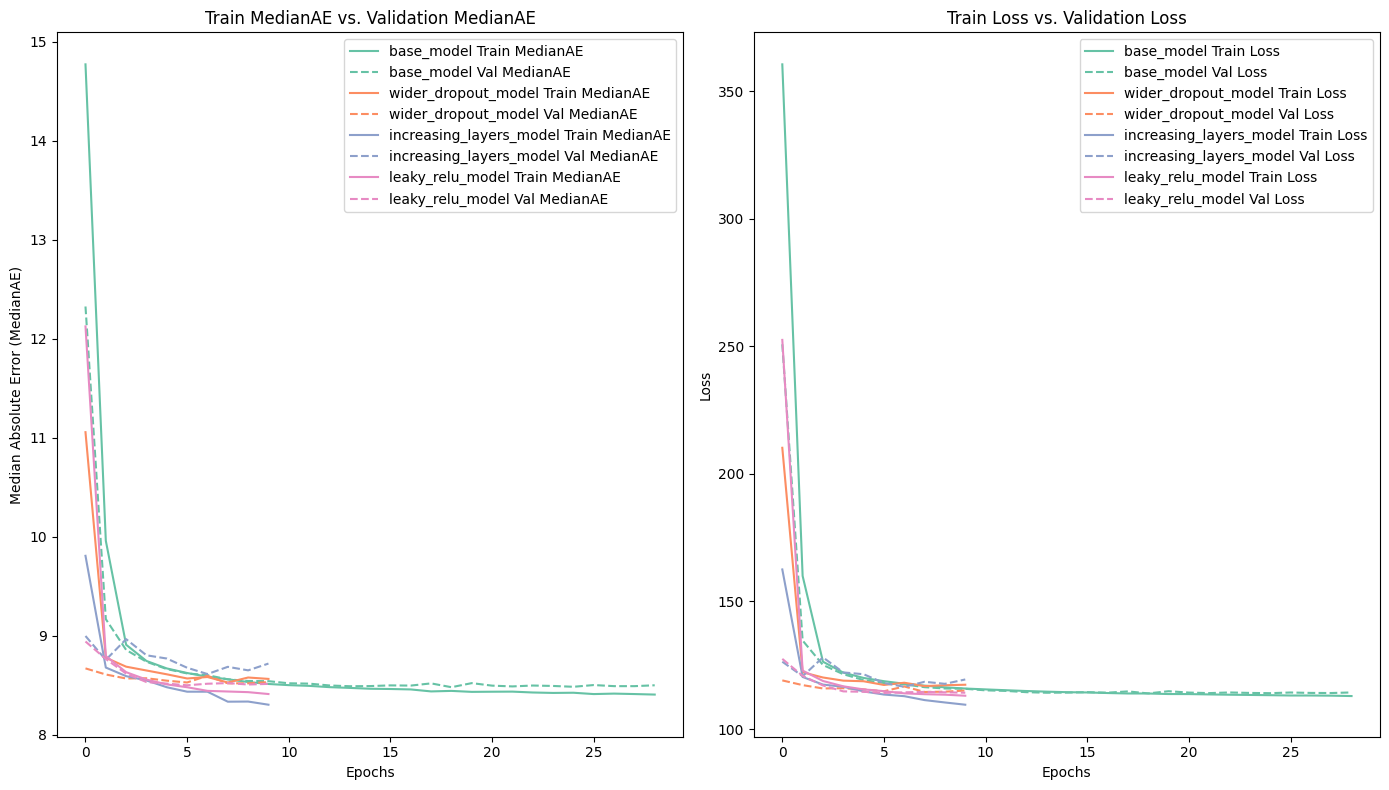

LEARNING RATE=0.0001, BATCH_SIZE=8, EPOCHS=50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 110.1314 - mae: 8.4606
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 197.7775 - mae: 11.0313
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 269.5186 - mae: 12.7031
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 129.7533 - mae: 9.0945  
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 144.2121 - mae: 9.5625  
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 179.9617 - mae: 10.1239 
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 118.9772 - mae: 8.6980
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 160.6150 - mae: 10.0376
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 164.7077 - mae: 10.0587
45

None

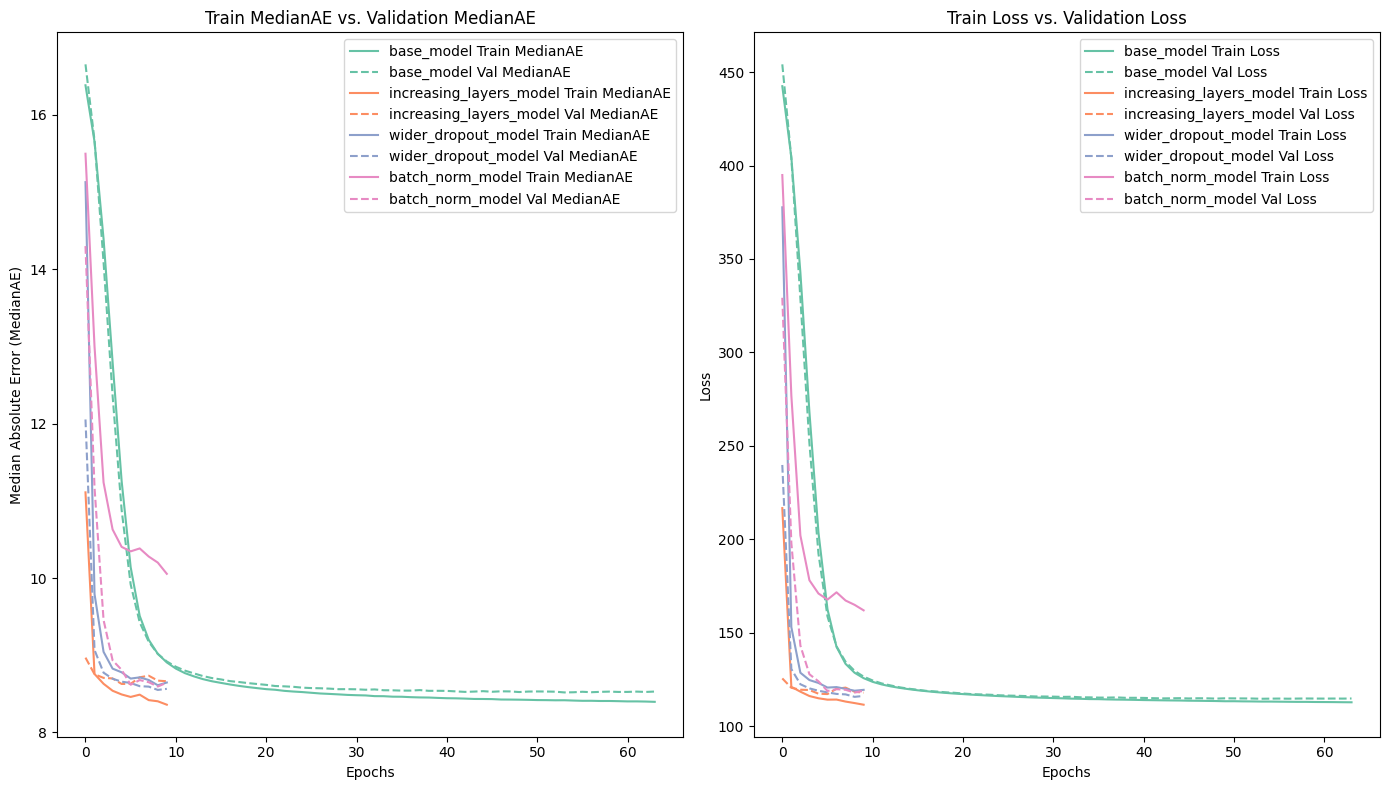

LEARNING RATE=5e-05, BATCH_SIZE=16, EPOCHS=100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 110.2212 - mae: 8.4807
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 399.9646 - mae: 15.5180
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 436.0529 - mae: 16.1888
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 367.0686 - mae: 14.8123
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 412.5107 - mae: 15.7089
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 442.9104 - mae: 16.0752 
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 123.1926 - mae: 8.9494
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 427.7916 - mae: 16.0292
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 445.5146 - mae: 16.3569
45/

None

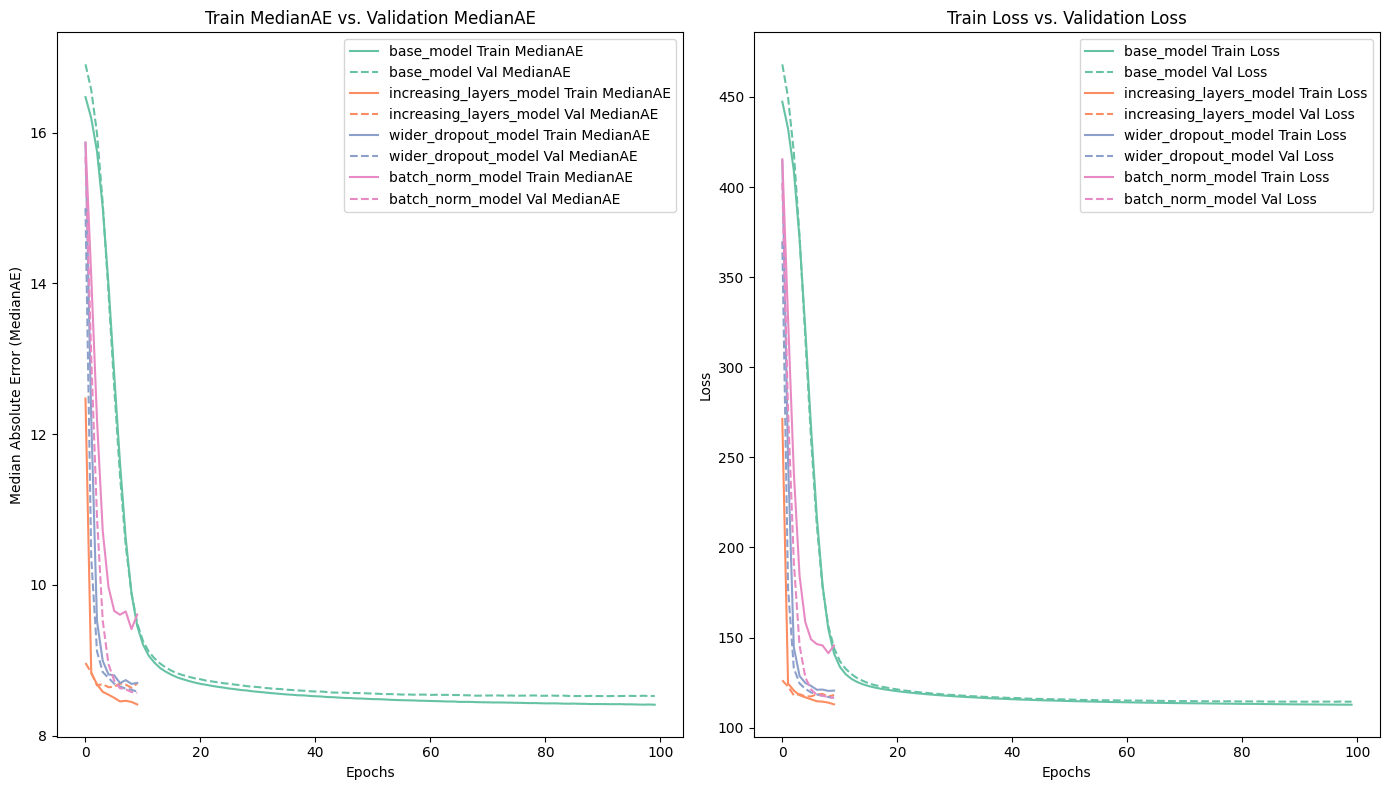

None

In [36]:
all_results_df = pd.DataFrame()

hyperparameters = [
    {'learning_rate': 0.1, 'batch_size': 8, 'epochs': 50, 'exclude_names': None, 'plot': False},
    {'learning_rate': 0.1, 'batch_size': 16, 'epochs': 50, 'exclude_names': None, 'plot': False},
    {'learning_rate': 0.01, 'batch_size': 32, 'epochs': 50, 'exclude_names': None},
    {'learning_rate': 0.01, 'batch_size': 64, 'epochs': 50, 'exclude_names': None},
    {'learning_rate': 0.01, 'batch_size': 128, 'epochs': 50, 'exclude_names': None},
    {'learning_rate': 0.001, 'batch_size': 16, 'epochs': 50, 'exclude_names': None},
    {'learning_rate': 0.001, 'batch_size': 32, 'epochs': 50, 'exclude_names': None},
    {'learning_rate': 0.001, 'batch_size': 64, 'epochs': 50, 'exclude_names': None},
    {'learning_rate': 0.0001, 'batch_size': 4, 'epochs': 50, 'exclude_names': None},
    {'learning_rate': 0.0001, 'batch_size': 8, 'epochs': 50, 'exclude_names': None, 'plot': False},
    {'learning_rate': 0.0001, 'batch_size': 16, 'epochs': 50, 'exclude_names': None, 'plot': False},
]


for params in hyperparameters:
    print(f"LEARNING RATE={params['learning_rate']}, BATCH_SIZE={params['batch_size']}, EPOCHS={params['epochs']}")
    
    histories, metrics, results_df = train_and_evaluate_models_with_features(
        games_lines_drives, feats_to_use, learning_rate=params['learning_rate'], 
        batch_size=params['batch_size'], epochs=params['epochs'], target='full_game_home_score_diff'
    )
    
    all_results_df = pd.concat([all_results_df, results_df], ignore_index=True)
    if params.get('plot', True):
        sorted_results_df = results_df.sort_values(by="R² Score", ascending=False)
        display(sorted_results_df)
        
        top_4_models = results_df.sort_values(by="R² Score", ascending=False).head(4)
        top_4_histories = {model_name: histories[model_name] for model_name in top_4_models['Model Name']}
        plot_model_performance(top_4_histories, exclude_names=params['exclude_names'])
        
display(all_results_df.sort_values(by="R² Score", ascending=False, inplace=True))

In [37]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 1000)


top_30_by_R2 = all_results_df.sort_values(by='R² Score', ascending=False).head(10)
print("\nTop 30 by R² Score:")
display(top_30_by_R2)

worst_30_by_R2 = all_results_df.sort_values(by='R² Score', ascending=True).head(10)
print("\nWorst 30 by R² Score:")
display(worst_30_by_R2)

worst_10_by_medianAE = all_results_df.sort_values(by='MedianAE', ascending=False).head(10)
print("Worst 10 by MedianAE:")
display(worst_10_by_medianAE)

top_10_by_medianAE = all_results_df.sort_values(by='MedianAE', ascending=True).head(10)
print("Top 10 by MedianAE:")
display(top_10_by_medianAE)


Top 30 by R² Score:


,Model Name,Params,R² Score,Explained Variance Score,MeanAE,MedianAE
58,deeper_dropout_model,"{'learning_rate': 0.001, 'batch_size': 32, 'epochs': 50}",0.753384,0.753420,8.482857,6.970379
54,base_model,"{'learning_rate': 0.001, 'batch_size': 32, 'epochs': 50}",0.752714,0.753004,8.509922,7.252049
71,sgd_model,"{'learning_rate': 0.001, 'batch_size': 64, 'epochs': 50}",0.752542,0.752550,8.499634,7.104438
9,base_model,"{'learning_rate': 0.1, 'batch_size': 16, 'epochs': 50}",0.752503,0.752987,8.483991,7.030915
72,base_model,"{'learning_rate': 0.0001, 'batch_size': 4, 'epochs': 50}",0.752406,0.752437,8.480120,7.100240
53,sgd_model,"{'learning_rate': 0.001, 'batch_size': 16, 'epochs': 50}",0.752201,0.752228,8.501286,6.939172
49,deeper_dropout_model,"{'learning_rate': 0.001, 'batch_size': 16, 'epochs': 50}",0.752155,0.752212,8.497854,7.011062
48,wider_dropout_model,"{'learning_rate': 0.001, 'batch_size': 16, 'epochs': 50}",0.752101,0.752693,8.486311,6.946832
45,base_model,"{'learning_rate': 0.001, 'batch_size': 16, 'epochs': 50}",0.751966,0.752344,8.510207,7.055194
35,sgd_model,"{'learning_rate': 0.01, 'batch_size': 64, 'epochs': 50}",0.751956,0.752311,8.514603,7.119634



Worst 30 by R² Score:


,Model Name,Params,R² Score,Explained Variance Score,MeanAE,MedianAE
15,increasing_layers_model,"{'learning_rate': 0.1, 'batch_size': 16, 'epochs': 50}",-0.053061,0.000000,17.232945,14.528800
6,increasing_layers_model,"{'learning_rate': 0.1, 'batch_size': 8, 'epochs': 50}",-0.028131,0.000000,17.006934,14.185274
13,deeper_dropout_model,"{'learning_rate': 0.1, 'batch_size': 16, 'epochs': 50}",-0.003353,0.000000,16.791747,13.829362
4,deeper_dropout_model,"{'learning_rate': 0.1, 'batch_size': 8, 'epochs': 50}",-0.000022,0.000000,16.811213,13.687077
116,sgd_model,"{'learning_rate': 5e-05, 'batch_size': 16, 'epochs': 100}",0.025891,0.065857,16.555666,13.615695
101,dropout_model,"{'learning_rate': 5e-05, 'batch_size': 8, 'epochs': 100}",0.043865,0.079451,16.392535,13.431390
110,dropout_model,"{'learning_rate': 5e-05, 'batch_size': 16, 'epochs': 100}",0.045570,0.079806,16.391757,13.427942
113,l1_l2_regularized_model,"{'learning_rate': 5e-05, 'batch_size': 16, 'epochs': 100}",0.058481,0.085041,16.283070,13.337438
115,leaky_relu_model,"{'learning_rate': 5e-05, 'batch_size': 16, 'epochs': 100}",0.063977,0.090782,16.225478,13.228879
112,deeper_dropout_model,"{'learning_rate': 5e-05, 'batch_size': 16, 'epochs': 100}",0.096486,0.106281,15.913141,13.034634


Worst 10 by MedianAE:


,Model Name,Params,R² Score,Explained Variance Score,MeanAE,MedianAE
15,increasing_layers_model,"{'learning_rate': 0.1, 'batch_size': 16, 'epochs': 50}",-0.053061,0.000000,17.232945,14.528800
6,increasing_layers_model,"{'learning_rate': 0.1, 'batch_size': 8, 'epochs': 50}",-0.028131,0.000000,17.006934,14.185274
13,deeper_dropout_model,"{'learning_rate': 0.1, 'batch_size': 16, 'epochs': 50}",-0.003353,0.000000,16.791747,13.829362
4,deeper_dropout_model,"{'learning_rate': 0.1, 'batch_size': 8, 'epochs': 50}",-0.000022,0.000000,16.811213,13.687077
116,sgd_model,"{'learning_rate': 5e-05, 'batch_size': 16, 'epochs': 100}",0.025891,0.065857,16.555666,13.615695
101,dropout_model,"{'learning_rate': 5e-05, 'batch_size': 8, 'epochs': 100}",0.043865,0.079451,16.392535,13.431390
110,dropout_model,"{'learning_rate': 5e-05, 'batch_size': 16, 'epochs': 100}",0.045570,0.079806,16.391757,13.427942
113,l1_l2_regularized_model,"{'learning_rate': 5e-05, 'batch_size': 16, 'epochs': 100}",0.058481,0.085041,16.283070,13.337438
115,leaky_relu_model,"{'learning_rate': 5e-05, 'batch_size': 16, 'epochs': 100}",0.063977,0.090782,16.225478,13.228879
112,deeper_dropout_model,"{'learning_rate': 5e-05, 'batch_size': 16, 'epochs': 100}",0.096486,0.106281,15.913141,13.034634


Top 10 by MedianAE:


,Model Name,Params,R² Score,Explained Variance Score,MeanAE,MedianAE
22,deeper_dropout_model,"{'learning_rate': 0.01, 'batch_size': 32, 'epochs': 50}",0.751827,0.751880,8.490994,6.863764
65,dropout_model,"{'learning_rate': 0.001, 'batch_size': 64, 'epochs': 50}",0.751895,0.751961,8.491328,6.864883
53,sgd_model,"{'learning_rate': 0.001, 'batch_size': 16, 'epochs': 50}",0.752201,0.752228,8.501286,6.939172
48,wider_dropout_model,"{'learning_rate': 0.001, 'batch_size': 16, 'epochs': 50}",0.752101,0.752693,8.486311,6.946832
58,deeper_dropout_model,"{'learning_rate': 0.001, 'batch_size': 32, 'epochs': 50}",0.753384,0.753420,8.482857,6.970379
20,dropout_model,"{'learning_rate': 0.01, 'batch_size': 32, 'epochs': 50}",0.748972,0.749889,8.511828,6.976727
29,dropout_model,"{'learning_rate': 0.01, 'batch_size': 64, 'epochs': 50}",0.751559,0.751871,8.488656,6.987869
49,deeper_dropout_model,"{'learning_rate': 0.001, 'batch_size': 16, 'epochs': 50}",0.752155,0.752212,8.497854,7.011062
9,base_model,"{'learning_rate': 0.1, 'batch_size': 16, 'epochs': 50}",0.752503,0.752987,8.483991,7.030915
90,base_model,"{'learning_rate': 0.0001, 'batch_size': 16, 'epochs': 50}",0.751888,0.751939,8.519224,7.033465


# Non Neural Net Models

In [24]:
def train_and_evaluate_models_feature_importance(games_lines_drives, feats_to_use, target="full_game_home_score_diff", test_size=0.2, random_state=42):
    X = games_lines_drives[feats_to_use].values
    y = games_lines_drives[target].values
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    models = {
        "Decision Tree": DecisionTreeRegressor(),
        "Random Forest": RandomForestRegressor(),
        "Gradient Boosting": GradientBoostingRegressor(),
        "Support Vector Regression": SVR(),
        "Linear Regression": LinearRegression(),
        "Ridge Regression": Ridge(),
        "Lasso Regression": Lasso()
    }

    param_grids = {
        "Decision Tree": {"max_depth": [5, 10, 15], "min_samples_split": [2, 5]},
        "Random Forest": {"n_estimators": [50, 100], "max_depth": [5, 10]},
        "Gradient Boosting": {"n_estimators": [50, 100], "learning_rate": [0.05, 0.1]},
        "Support Vector Regression": {"C": [1, 10], "gamma": ["scale", "auto"]},
        "Linear Regression": {},
        "Ridge Regression": {"alpha": [0.1, 1, 10]},
        "Lasso Regression": {"alpha": [0.1, 1, 10]}
    }

    results = []
    for name, model in models.items():
        grid_search = GridSearchCV(estimator=model, param_grid=param_grids[name], cv=5, scoring='neg_mean_squared_error')
        grid_search.fit(X_train_scaled, y_train)
        best_model = grid_search.best_estimator_
        y_pred = best_model.predict(X_test_scaled)
        r2 = r2_score(y_test, y_pred)
        evs = explained_variance_score(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        medae = median_absolute_error(y_test, y_pred)

        if hasattr(best_model, 'feature_importances_'):
            feature_importance = best_model.feature_importances_
            feature_importance_dict = {feats_to_use[i]: feature_importance[i] for i in range(len(feats_to_use))}
        elif hasattr(best_model, 'coef_'):
            feature_importance = np.abs(best_model.coef_)
            feature_importance_dict = {feats_to_use[i]: feature_importance[i] for i in range(len(feats_to_use))}
        else:
            feature_importance_dict = None
        results.append([name, grid_search.best_params_, r2, evs, mae, medae, feature_importance_dict])
    results_df = pd.DataFrame(results, columns=["Model Name", "Best Params", "R² Score", "Explained Variance", "MeanAE", "MedianAE", "Feature Importance"])
    return results_df

Feature engineering was applied to non-neural network models with a focus on improving their performance. The feature importance was largely driven by spread and halftime_home_score_diff. My goal was to reduce their influence while enhancing the other metrics. The plot below was created to determine if log transformations would be needed on either spread or halftime_home_score_diff. The general cloud-like shape shows randomness and the model is working well for those features.

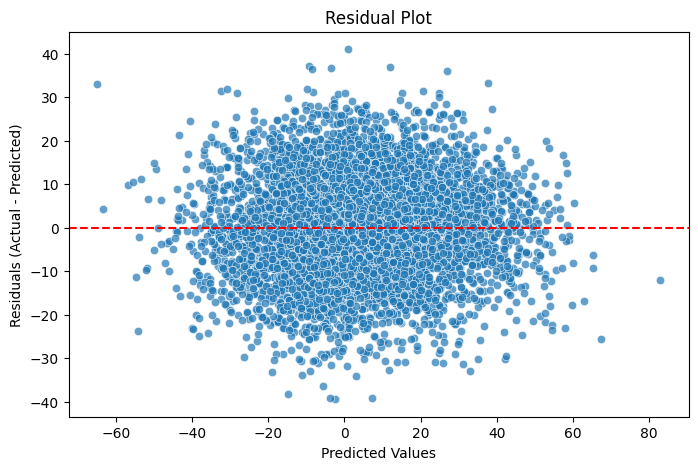

In [ ]:
X = games_lines_drives[['spread', 'halftime_home_score_diff']]
y = games_lines_drives['full_game_home_score_diff']

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
residuals = y - y_pred

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot")
plt.show()

In [26]:
gld_temp = games_lines_drives.copy()
gld_temp['overUnder_x_halftime_x_home_diff'] = (gld_temp['overUnder'] * gld_temp['halftime_total_points'] * gld_temp['halftime_home_score_diff'])


feat_eng_1 = train_and_evaluate_models_feature_importance(games_lines_drives, feats_to_use, target="full_game_home_score_diff", test_size=0.2, random_state=42)
display(feat_eng_1)

,Model Name,Best Params,R² Score,Explained Variance,MeanAE,MedianAE,Feature Importance
0,Decision Tree,"{'max_depth': 5, 'min_samples_split': 2}",0.722601,0.722603,8.883146,7.434211,"{'spread': 0.11675471506686429, 'overUnder': 0.0, 'home_drive_count': 0.0, 'away_drive_count': 0.0, 'home_sum_plays': 0.0, 'away_sum_plays': 0.0, 'home_total_yards': 0.0, 'away_total_yards': 0.0, 'halftime_total_points': 0.0, 'halftime_home_score_diff': 0.8832452849331357}"
1,Random Forest,"{'max_depth': 5, 'n_estimators': 100}",0.743374,0.743375,8.622442,6.979016,"{'spread': 0.11181594670551954, 'overUnder': 0.0006297447105182267, 'home_drive_count': 0.00015470761976428757, 'away_drive_count': 0.00019066220466623516, 'home_sum_plays': 0.00039995198202820914, 'away_sum_plays': 0.0003717183445530535, 'home_total_yards': 0.0006978272844826845, 'away_total_yards': 0.0005258927482337955, 'halftime_total_points': 0.0003356391767523486, 'halftime_home_score_diff': 0.8848779092234816}"
2,Gradient Boosting,"{'learning_rate': 0.1, 'n_estimators': 100}",0.744406,0.744409,8.631029,7.119095,"{'spread': 0.13032787546648716, 'overUnder': 0.003245917260798352, 'home_drive_count': 0.0015993680628796697, 'away_drive_count': 0.0004284111217260647, 'home_sum_plays': 0.00391724085565868, 'away_sum_plays': 0.002891677299648609, 'home_total_yards': 0.005386687721159831, 'away_total_yards': 0.0035719084204959535, 'halftime_total_points': 0.0023078977382555324, 'halftime_home_score_diff': 0.8463230160528902}"
3,Support Vector Regression,"{'C': 10, 'gamma': 'scale'}",0.725559,0.725561,8.911067,7.389025,None
4,Linear Regression,{},0.752586,0.752586,8.482215,7.036073,"{'spread': 6.225783679665312, 'overUnder': 0.02754624492751835, 'home_drive_count': 0.7197150995959504, 'away_drive_count': 0.40112277196558654, 'home_sum_plays': 0.4102060393299206, 'away_sum_plays': 0.09616006498430289, 'home_total_yards': 0.6823569101492196, 'away_total_yards': 0.5662162917355184, 'halftime_total_points': 0.1621668755530471, 'halftime_home_score_diff': 12.890387938567612}"
5,Ridge Regression,{'alpha': 10},0.752491,0.752491,8.483783,7.049155,"{'spread': 6.221793300747564, 'overUnder': 0.029279444854526947, 'home_drive_count': 0.7289842231639119, 'away_drive_count': 0.4109856460754852, 'home_sum_plays': 0.4207205541469946, 'away_sum_plays': 0.10765682860347113, 'home_total_yards': 0.7307705953243689, 'away_total_yards': 0.6204658134959502, 'halftime_total_points': 0.16743575985869374, 'halftime_home_score_diff': 12.810683559152876}"
6,Lasso Regression,{'alpha': 0.1},0.751932,0.751932,8.497336,7.130373,"{'spread': 6.238991206356659, 'overUnder': 0.0, 'home_drive_count': 0.30064599124553837, 'away_drive_count': 0.0, 'home_sum_plays': 0.20516563614921635, 'away_sum_plays': 0.0, 'home_total_yards': 0.38897637316683026, 'away_total_yards': 0.12377986350014948, 'halftime_total_points': 0.0, 'halftime_home_score_diff': 13.215787871747812}"


In [27]:
temp_feats_to_use = ['spread', 'home_drive_count', 'away_drive_count',
       'home_sum_plays', 'away_sum_plays', 'home_total_yards', 'away_total_yards','overUnder_x_halftime_x_home_diff']

gld_temp = games_lines_drives.copy()
gld_temp['overUnder_x_halftime_x_home_diff'] = (gld_temp['overUnder'] * gld_temp['halftime_total_points'] * gld_temp['halftime_home_score_diff'])

feat_eng_2 = train_and_evaluate_models_feature_importance(gld_temp, temp_feats_to_use, target="full_game_home_score_diff", test_size=0.2, random_state=42)
display(feat_eng_2)

,Model Name,Best Params,R² Score,Explained Variance,MeanAE,MedianAE,Feature Importance
0,Decision Tree,"{'max_depth': 5, 'min_samples_split': 2}",0.706754,0.706783,9.262707,7.844417,"{'spread': 0.13358757276482816, 'home_drive_count': 0.0, 'away_drive_count': 0.0, 'home_sum_plays': 0.0, 'away_sum_plays': 0.0, 'home_total_yards': 0.004607515479482153, 'away_total_yards': 0.01040668123925414, 'overUnder_x_halftime_x_home_diff': 0.8513982305164357}"
1,Random Forest,"{'max_depth': 10, 'n_estimators': 100}",0.726269,0.726305,8.938368,7.413370,"{'spread': 0.1406473035756998, 'home_drive_count': 0.008976315262337173, 'away_drive_count': 0.00851627405085048, 'home_sum_plays': 0.0187907710049179, 'away_sum_plays': 0.021461808560125663, 'home_total_yards': 0.03658619170100094, 'away_total_yards': 0.03996643488478682, 'overUnder_x_halftime_x_home_diff': 0.7250549009602814}"
2,Gradient Boosting,"{'learning_rate': 0.1, 'n_estimators': 100}",0.733464,0.733504,8.821936,7.422611,"{'spread': 0.16901278497613684, 'home_drive_count': 0.0011089863325352979, 'away_drive_count': 0.0005887180981313582, 'home_sum_plays': 0.00397973486522449, 'away_sum_plays': 0.0023769074462747777, 'home_total_yards': 0.017609008020089842, 'away_total_yards': 0.021431203740859803, 'overUnder_x_halftime_x_home_diff': 0.7838926565207477}"
3,Support Vector Regression,"{'C': 10, 'gamma': 'auto'}",0.708017,0.708059,9.202895,7.735196,None
4,Linear Regression,{},0.704293,0.704338,9.260859,7.741448,"{'spread': 6.913820232690635, 'home_drive_count': 1.552125399231392, 'away_drive_count': 1.270086917531394, 'home_sum_plays': 0.8883884063405957, 'away_sum_plays': 0.5246333480356452, 'home_total_yards': 3.888884242181607, 'away_total_yards': 4.027756503011557, 'overUnder_x_halftime_x_home_diff': 7.683396399820634}"
5,Ridge Regression,{'alpha': 10},0.704235,0.704280,9.261365,7.740577,"{'spread': 6.907561813926338, 'home_drive_count': 1.5455122964230155, 'away_drive_count': 1.2646648572495902, 'home_sum_plays': 0.8853502592134729, 'away_sum_plays': 0.5217645637156557, 'home_total_yards': 3.8881892072869793, 'away_total_yards': 4.025852752871081, 'overUnder_x_halftime_x_home_diff': 7.674144639809274}"
6,Lasso Regression,{'alpha': 0.1},0.703182,0.703232,9.268137,7.767972,"{'spread': 6.94899525059728, 'home_drive_count': 1.122918693961074, 'away_drive_count': 0.8479537928781702, 'home_sum_plays': 0.7155852830967961, 'away_sum_plays': 0.34008805851032087, 'home_total_yards': 3.5473416580499593, 'away_total_yards': 3.6931080882600154, 'overUnder_x_halftime_x_home_diff': 7.919243855761411}"


In [28]:
temp_feats_to_use = ['log_spread', 'overUnder', 'home_drive_count', 'away_drive_count',
       'home_sum_plays', 'away_sum_plays', 'home_total_yards', 'away_total_yards',
       'halftime_total_points', 'log_halftime_home_score_diff']


gld_temp = games_lines_drives.copy()
gld_temp['log_spread'] = np.sign(gld_temp['spread']) * np.log1p(abs(gld_temp['spread']))
gld_temp['log_halftime_home_score_diff'] = np.sign(gld_temp['halftime_home_score_diff']) * np.log1p(abs(gld_temp['halftime_home_score_diff']))
feat_eng_3 = train_and_evaluate_models_feature_importance(gld_temp, temp_feats_to_use, target="full_game_home_score_diff", test_size=0.2, random_state=42)
display(feat_eng_3)

,Model Name,Best Params,R² Score,Explained Variance,MeanAE,MedianAE,Feature Importance
0,Decision Tree,"{'max_depth': 5, 'min_samples_split': 2}",0.722601,0.722603,8.883146,7.434211,"{'log_spread': 0.11675471506686429, 'overUnder': 0.0, 'home_drive_count': 0.0, 'away_drive_count': 0.0, 'home_sum_plays': 0.0, 'away_sum_plays': 0.0, 'home_total_yards': 0.0, 'away_total_yards': 0.0, 'halftime_total_points': 0.0, 'log_halftime_home_score_diff': 0.8832452849331357}"
1,Random Forest,"{'max_depth': 5, 'n_estimators': 100}",0.743187,0.743187,8.612667,7.118695,"{'log_spread': 0.11141525070479634, 'overUnder': 0.0007492328282444545, 'home_drive_count': 0.00012888560821560667, 'away_drive_count': 0.00019466216767671622, 'home_sum_plays': 0.00046428703143876324, 'away_sum_plays': 0.00033012956822297016, 'home_total_yards': 0.0009854461996178414, 'away_total_yards': 0.00047102385373353904, 'halftime_total_points': 0.0002828779564707777, 'log_halftime_home_score_diff': 0.884978204081583}"
2,Gradient Boosting,"{'learning_rate': 0.1, 'n_estimators': 100}",0.744317,0.744320,8.631345,7.119095,"{'log_spread': 0.13032717387283324, 'overUnder': 0.0032459172607985118, 'home_drive_count': 0.0016265966420957833, 'away_drive_count': 0.00045025703911517277, 'home_sum_plays': 0.003909125848374376, 'away_sum_plays': 0.0028771759505726922, 'home_total_yards': 0.005447394721441068, 'away_total_yards': 0.0035729814984986805, 'halftime_total_points': 0.002266440890498988, 'log_halftime_home_score_diff': 0.8462769362757715}"
3,Support Vector Regression,"{'C': 10, 'gamma': 'auto'}",0.707882,0.708076,9.193561,7.668669,None
4,Linear Regression,{},0.703555,0.703609,9.322527,8.009397,"{'log_spread': 5.740759384766243, 'overUnder': 0.3458765344454525, 'home_drive_count': 1.5846545282085929, 'away_drive_count': 1.4746967272581564, 'home_sum_plays': 1.4975355617993098, 'away_sum_plays': 0.961763169318183, 'home_total_yards': 4.024649824045038, 'away_total_yards': 4.4728083041250315, 'halftime_total_points': 0.9350290161836576, 'log_halftime_home_score_diff': 8.49517315927747}"
5,Ridge Regression,{'alpha': 10},0.703474,0.703527,9.323318,8.006419,"{'log_spread': 5.738262308630828, 'overUnder': 0.34563656881670646, 'home_drive_count': 1.5775715947715276, 'away_drive_count': 1.4689216436059962, 'home_sum_plays': 1.4928160609053043, 'away_sum_plays': 0.9568070488459993, 'home_total_yards': 4.024522791527395, 'away_total_yards': 4.468094123726722, 'halftime_total_points': 0.9319420399017346, 'log_halftime_home_score_diff': 8.482721248890256}"
6,Lasso Regression,{'alpha': 0.1},0.702586,0.702639,9.334474,8.087670,"{'log_spread': 5.762470335303835, 'overUnder': 0.23178152115242623, 'home_drive_count': 1.135740352093165, 'away_drive_count': 1.0933351110693499, 'home_sum_plays': 1.354707172708357, 'away_sum_plays': 0.7880117111195512, 'home_total_yards': 3.892466294312695, 'away_total_yards': 3.995524591870438, 'halftime_total_points': 0.7107483539784039, 'log_halftime_home_score_diff': 8.709328993798183}"


In [29]:
temp_feats_to_use = ['spread', 'overUnder', 'home_drive_diff',
       'home_yards_per_play', 'away_yards_per_play',
       'halftime_total_points', 'halftime_home_score_diff']

gld_temp = games_lines_drives.copy()
gld_temp['home_yards_per_play'] = gld_temp['home_total_yards'] / gld_temp['home_sum_plays']
gld_temp['away_yards_per_play'] = gld_temp['away_total_yards'] / gld_temp['away_sum_plays']
gld_temp['home_drive_diff'] = gld_temp['home_drive_count'] - gld_temp['away_drive_count']

feat_eng_4 = train_and_evaluate_models_feature_importance(games_lines_drives, feats_to_use, target="full_game_home_score_diff", test_size=0.2, random_state=42)
display(feat_eng_4)

,Model Name,Best Params,R² Score,Explained Variance,MeanAE,MedianAE,Feature Importance
0,Decision Tree,"{'max_depth': 5, 'min_samples_split': 2}",0.722601,0.722603,8.883146,7.434211,"{'spread': 0.11675471506686429, 'overUnder': 0.0, 'home_drive_count': 0.0, 'away_drive_count': 0.0, 'home_sum_plays': 0.0, 'away_sum_plays': 0.0, 'home_total_yards': 0.0, 'away_total_yards': 0.0, 'halftime_total_points': 0.0, 'halftime_home_score_diff': 0.8832452849331357}"
1,Random Forest,"{'max_depth': 5, 'n_estimators': 50}",0.743805,0.743806,8.597984,7.136182,"{'spread': 0.11189673578062713, 'overUnder': 0.0005564953179937501, 'home_drive_count': 0.00015785407347531345, 'away_drive_count': 5.445929870218005e-05, 'home_sum_plays': 0.00034673421159279593, 'away_sum_plays': 0.0003171262733131223, 'home_total_yards': 0.0010815802940364687, 'away_total_yards': 0.000506074297295258, 'halftime_total_points': 0.00046330992620451864, 'halftime_home_score_diff': 0.8846196305267595}"
2,Gradient Boosting,"{'learning_rate': 0.1, 'n_estimators': 100}",0.744399,0.744402,8.628873,7.119095,"{'spread': 0.13041868396436135, 'overUnder': 0.0032464092275203004, 'home_drive_count': 0.001633427838094057, 'away_drive_count': 0.00044913451999663203, 'home_sum_plays': 0.003934958348690855, 'away_sum_plays': 0.002850898239513958, 'home_total_yards': 0.005304215923779036, 'away_total_yards': 0.003604702638610616, 'halftime_total_points': 0.0022585416710159093, 'halftime_home_score_diff': 0.8462990276284174}"
3,Support Vector Regression,"{'C': 10, 'gamma': 'scale'}",0.725559,0.725561,8.911067,7.389025,None
4,Linear Regression,{},0.752586,0.752586,8.482215,7.036073,"{'spread': 6.225783679665312, 'overUnder': 0.02754624492751835, 'home_drive_count': 0.7197150995959504, 'away_drive_count': 0.40112277196558654, 'home_sum_plays': 0.4102060393299206, 'away_sum_plays': 0.09616006498430289, 'home_total_yards': 0.6823569101492196, 'away_total_yards': 0.5662162917355184, 'halftime_total_points': 0.1621668755530471, 'halftime_home_score_diff': 12.890387938567612}"
5,Ridge Regression,{'alpha': 10},0.752491,0.752491,8.483783,7.049155,"{'spread': 6.221793300747564, 'overUnder': 0.029279444854526947, 'home_drive_count': 0.7289842231639119, 'away_drive_count': 0.4109856460754852, 'home_sum_plays': 0.4207205541469946, 'away_sum_plays': 0.10765682860347113, 'home_total_yards': 0.7307705953243689, 'away_total_yards': 0.6204658134959502, 'halftime_total_points': 0.16743575985869374, 'halftime_home_score_diff': 12.810683559152876}"
6,Lasso Regression,{'alpha': 0.1},0.751932,0.751932,8.497336,7.130373,"{'spread': 6.238991206356659, 'overUnder': 0.0, 'home_drive_count': 0.30064599124553837, 'away_drive_count': 0.0, 'home_sum_plays': 0.20516563614921635, 'away_sum_plays': 0.0, 'home_total_yards': 0.38897637316683026, 'away_total_yards': 0.12377986350014948, 'halftime_total_points': 0.0, 'halftime_home_score_diff': 13.215787871747812}"


In [30]:
def train_and_evaluate_models_with_gridsearch(games_lines_drives, feats_to_use, target="full_game_total_points", test_size=0.2, random_state=42):
    X = games_lines_drives[feats_to_use].values
    y = games_lines_drives[target].values
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    param_grids = {
        "Linear Regression": {},
        "Ridge Regression": {"alpha": [0.1, 1.0, 10.0]},
        "Lasso Regression": {"alpha": [0.01, 0.1, 1.0]},
        "Decision Tree": {"max_depth": [5, 10, 15], "min_samples_split": [2, 5, 10]},
        "Random Forest": {"n_estimators": [50, 100, 200], "max_depth": [5, 10, 15], "min_samples_split": [2, 5, 10]},
        "Gradient Boosting": {"n_estimators": [50, 100], "learning_rate": [0.05, 0.1, 0.2], "max_depth": [3, 5, 7]},
        "Support Vector Regression": {"C": [0.1, 1.0, 10.0], "epsilon": [0.01, 0.1, 0.2]}
    }

    models = {
        "Linear Regression": LinearRegression(),
        "Ridge Regression": Ridge(),
        "Lasso Regression": Lasso(),
        "Decision Tree": DecisionTreeRegressor(),
        "Random Forest": RandomForestRegressor(),
        "Gradient Boosting": GradientBoostingRegressor(),
        "Support Vector Regression": SVR()
    }

    results_df = pd.DataFrame(columns=["Model Name", "Best Params", "R² Score", "Explained Variance Score", "MeanAE", "MedianAE"])
    metrics_dict = {}

    def train_and_evaluate_model(model, name, param_grid):
        grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, n_jobs=-1, scoring='neg_mean_squared_error')
        grid_search.fit(X_train, y_train)
        
        best_model = grid_search.best_estimator_
        best_params = grid_search.best_params_
        y_pred = best_model.predict(X_test)

        metrics_dict[name] = {
            "R² Score": r2_score(y_test, y_pred),
            "Explained Variance Score": explained_variance_score(y_test, y_pred),
            "MeanAE": mean_absolute_error(y_test, y_pred),
            "MedianAE": median_absolute_error(y_test, y_pred)
        }

        results_df.loc[len(results_df)] = [
            name,
            best_params,
            metrics_dict[name]["R² Score"],
            metrics_dict[name]["Explained Variance Score"],
            metrics_dict[name]["MeanAE"],
            metrics_dict[name]["MedianAE"]
        ]

    for name, model in models.items():
        param_grid = param_grids.get(name, {})
        train_and_evaluate_model(model, name, param_grid)

    return metrics_dict, results_df

In [31]:
non_neural_metrics, non_neural_results_df = train_and_evaluate_models_with_gridsearch(games_lines_drives, feats_to_use, target='full_game_home_score_diff')

In [33]:
display(top_30_by_R2.head(10))
display(non_neural_results_df)

,Model Name,Params,R² Score,Explained Variance Score,MeanAE,MedianAE
97,leaky_relu_model,"{'learning_rate': 0.0001, 'batch_size': 8, 'epochs': 50}",0.753463,0.753571,8.483992,6.996841
74,dropout_model,"{'learning_rate': 0.001, 'batch_size': 32, 'epochs': 50}",0.753081,0.753100,8.492187,7.001884
54,base_model,"{'learning_rate': 0.01, 'batch_size': 128, 'epochs': 50}",0.752809,0.753236,8.509054,6.880622
93,wider_dropout_model,"{'learning_rate': 0.0001, 'batch_size': 8, 'epochs': 50}",0.752491,0.752492,8.491844,7.136240
107,sgd_model,"{'learning_rate': 0.0001, 'batch_size': 16, 'epochs': 50}",0.752265,0.752266,8.506823,7.040262
90,base_model,"{'learning_rate': 0.0001, 'batch_size': 8, 'epochs': 50}",0.752213,0.752230,8.509588,6.993882
65,dropout_model,"{'learning_rate': 0.001, 'batch_size': 16, 'epochs': 50}",0.752107,0.752202,8.505915,7.047245
53,sgd_model,"{'learning_rate': 0.01, 'batch_size': 128, 'epochs': 50}",0.751976,0.752067,8.494936,7.119743
99,base_model,"{'learning_rate': 0.0001, 'batch_size': 16, 'epochs': 50}",0.751797,0.751799,8.505472,7.040537
45,base_model,"{'learning_rate': 0.01, 'batch_size': 128, 'epochs': 50}",0.751765,0.751808,8.510689,7.019091


,Model Name,Best Params,R² Score,Explained Variance Score,MeanAE,MedianAE
0,Linear Regression,{},0.752586,0.752586,8.482215,7.036073
1,Ridge Regression,{'alpha': 10.0},0.752491,0.752491,8.483783,7.049155
2,Lasso Regression,{'alpha': 0.01},0.752547,0.752547,8.482996,7.015228
3,Decision Tree,"{'max_depth': 5, 'min_samples_split': 2}",0.722601,0.722603,8.883146,7.434211
4,Random Forest,"{'max_depth': 5, 'min_samples_split': 10, 'n_estimators': 50}",0.743530,0.743530,8.620539,7.239909
5,Gradient Boosting,"{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}",0.744280,0.744282,8.629928,7.119095
6,Support Vector Regression,"{'C': 10.0, 'epsilon': 0.2}",0.725848,0.725851,8.906773,7.403935


Non-neural Models:

- **Linear and Regularized Regression Models** (Linear, Ridge, and Lasso) show very similar R² and Explained Variance scores (around 0.752) with fairly close Mean and Median Absolute Errors (MeanAE ranging from 8.48 to 8.49, and MedianAE between 7.02 and 7.05). These models perform consistently well with minimal tuning.

- **Decision Tree** has a lower R² (0.722) and explained variance (0.722) compared to the other models, along with higher MeanAE and MedianAE values (8.88 and 7.43), suggesting it underperforms relative to the other methods.

- **Random Forest and Gradient Boosting** models show moderate improvements over the Decision Tree, with R² scores around 0.744 to 0.743, MeanAE between 8.62 and 8.63, and MedianAE ranging from 7.12 to 7.24. These ensemble models seem to offer more reliable performance compared to the Decision Tree.

- **Support Vector Regression** performs similarly to Random Forest and Gradient Boosting with a slightly lower R² score (0.725), but with the highest MeanAE (8.91) and MedianAE (7.40), indicating a bit more error than the ensemble models but still relatively competitive.

Simpler models like Linear Regression, Ridge, and Lasso perform consistently well, while more complex models like Random Forest, Gradient Boosting, and Support Vector Regression provide better results than Decision Trees but still don't significantly outperform the regression models in terms of R² and explained variance.


# Conclusions

1. Learning Rate:
   - Best: Lower learning rates like 0.0001, 0.001, and 0.01 tend to work better, especially for models like base_model, dropout_model, and leaky_relu_model.
   - Worst: Higher learning rates such as 0.1 tend to result in poor performance, with negative R² scores and high error metrics (e.g., leaky_relu_model and increasing_layers_model at 0.1).

2. Batch Size:
   - Best: Smaller batch sizes like 8, 16, and 32 lead to better performance, particularly in models like base_model, dropout_model, and leaky_relu_model.
   - Worst: Larger batch sizes, particularly 64 and 128, seem to have a negative effect, especially for the worse models where large batch sizes resulted in poor scores (e.g., increasing_layers_model with batch_size: 64).

3. Epochs:
   - Best: A consistent 50 epochs seems to perform well across models, both in the top 10 by MedianAE and R² score. There's no significant evidence that increasing epochs beyond 50 yields better results for most models.

4. Model Architecture:
   - Best Models: 
     - base_model (especially with learning_rate: 0.01 and small batch sizes like 32 and 128).
     - dropout_model and leaky_relu_model are also performing well at lower learning rates (0.0001, 0.001).
   - Worst Models:
     - increasing_layers_model and deeper_dropout_model performed poorly, especially when using high learning rates and large batch sizes.
     - leaky_relu_model with learning_rate: 0.1 also performed poorly.

5. Regularization:
   - Best Models: Regularization techniques such as dropout and batch normalization seem to improve the model performance, especially with lower learning rates.
   - Worst Models: Models that lack regularization (like increasing_layers_model and deeper_dropout_model at higher learning rates) tend to struggle, as they overfit or do not converge well.

Summary of Best and Worst Models:
- Top Models:
  - base_model with learning_rate: 0.01 and batch_size: 128 performs well across multiple metrics (R², Explained Variance, MedianAE).
  - dropout_model with learning_rate: 0.0001 and batch_size: 8 shows high performance with low error values.
  - leaky_relu_model at learning_rate: 0.0001 and batch_size: 8 also achieves good results with low median AE values.

- Worst Models:
  - increasing_layers_model with learning_rate: 0.1 and high batch sizes (16, 64) leads to negative results in all metrics.
  - deeper_dropout_model with higher learning rates (0.1) and smaller batch sizes (8, 16) performs poorly with high mean and median AE values.
  - leaky_relu_model with learning_rate: 0.1 also underperforms significantly, showing poor R² and high error values.

General Recommendations:
1. Learning Rate: Stick to values between 0.0001 and 0.01. Higher learning rates like 0.1 tend to cause instability and poor model performance.
2. Batch Size: Smaller batch sizes (8, 16, 32) tend to give better results. Larger batch sizes can worsen performance due to overfitting.
3. Regularization: Use dropout and batch normalization for better regularization, especially with smaller learning rates.
4. Model Choice: Simpler models like base_model or dropout_model with lower learning rates and regularization generally perform the best.
"""

**Summary**

Simpler versions of non neural net models are comparable to the neural net models. Despite high volume of data feel like it was simplistic enough where complex relationships did not exist or were dominated by a couple features. The best neural model was leaky_relu_model, slightly edging out others. Linear Regression, Ridge, and Lasso matched or exceeded most neural models. Tree-based models and SVR showed weaker performance, with lower R² and higher errors.